<a href="https://colab.research.google.com/github/youma-code/qqq/blob/main/%E9%96%8B%E7%99%BA1.8.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
import numpy as np
import pandas as pd
import yfinance as yf
import time

# ======================
# データ取得
# ======================
ticker = "QQQ"
start_date = "2020-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")

def download_data(ticker, start, end):
    for _ in range(5):
        df = yf.download(ticker, start=start, end=end)
        if not df.empty:
            return df
        time.sleep(3)
    return pd.DataFrame()

df = download_data(ticker, start_date, end_date)

# ======================
# 整形
# ======================
if isinstance(df.columns, pd.MultiIndex):
    df = df[['Close', 'High', 'Low', 'Volume']].droplevel(1, axis=1)
else:
    df = df[['Close', 'High', 'Low', 'Volume']].copy()

df.columns = ['Close', 'High', 'Low', 'Volume']
df.dropna(inplace=True)

# ======================
# 特徴量作成（強化版）
# ======================

# --- SMA系 ---
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_25"] = df["Close"].rolling(25).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()
df["SMA_DIFF"] = df["SMA_5"] - df["SMA_25"]
df["SMA_RATIO"] = df["SMA_5"] / (df["SMA_25"] + 1e-9)

# --- Target ---
future_max = df["Close"].shift(-1).rolling(3).max()
df["Target"] = ((future_max / df["Close"] - 1) > 0.0075).astype(int)

# --- RSI ---
delta = df["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss + 1e-9)
df["RSI"] = 100 - (100 / (1 + rs))

# --- MACD ---
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["MACD"] = ema12 - ema26
df["Signal_Line"] = df["MACD"].ewm(span=9).mean()
df["MACD_Hist"] = df["MACD"] - df["Signal_Line"]

# --- ボラ・リターン ---
df["Daily_Return"] = df["Close"].pct_change()
df["Volatility_Short"] = df["Daily_Return"].rolling(5).std()
# --- Volatility Expansion Ratio ---
df["Volatility_Expansion_Ratio"] = df["Daily_Return"].rolling(5).std() / df["Daily_Return"].rolling(window=20, min_periods=1).mean()

# --- ATR ---
tr = pd.concat([
    df["High"] - df["Low"],
    abs(df["High"] - df["Close"].shift()),
    abs(df["Low"] - df["Close"].shift())
], axis=1).max(axis=1)

df["ATR"] = tr.rolling(14).mean()

# ======================
# 🔥追加強化特徴量
# ======================

# モメンタム
df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

# ボラ構造
df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

# レンジ度
df["RANGE_SCORE"] = abs(df["RSI"] - 50)

# モメンタム補助
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ======================
# cleanup
# ======================
df = df.dropna()

# ======================
# ADX（ここが重要）
# ======================
window = 14

plus_dm = df["High"].diff()
minus_dm = -df["Low"].diff()

plus_dm = plus_dm.clip(lower=0)
minus_dm = minus_dm.clip(lower=0)

tr = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift()).abs(),
    (df["Low"] - df["Close"].shift()).abs()
], axis=1).max(axis=1)

atr = tr.rolling(window).mean()

plus_di = 100 * (plus_dm.rolling(window).mean() / (atr + 1e-9))
minus_di = 100 * (minus_dm.rolling(window).mean() / (atr + 1e-9))

dx = (abs(plus_di - minus_di) / (plus_di + minus_di + 1e-9)) * 100

df["ADX"] = dx.rolling(window).mean()

# ======================
# 追加特徴量（ADX後にやる！）
# ======================

df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

df["RANGE_SCORE"] = abs(df["RSI"] - 50)
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ★ここで初めて作る
df["TREND_STRENGTH"] = df["ADX"] * df["MACD_Hist"]

# --- BB ---
ma = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std()

df["Upper_BB"] = ma + 2 * std
df["Lower_BB"] = ma - 2 * std
df["BB_Width"] = (df["Upper_BB"] - df["Lower_BB"]) / (ma + 1e-9)

# --- lag ---
for lag in range(1, 6):
    df[f"Close_Lag_{lag}"] = df["Close"].shift(lag)

# ======================
# 🔥新規追加: レジーム分離と正規化ADX、市場レジーム
# ======================
df["ADX_normalized"] = df["ADX"] / 100  # ADXを0-1に正規化

# 新しいトレンド強度の計算
df["SMA_diff_abs"] = abs(df["SMA_50"] - df["SMA_200"])

# 初期データ準備ではデフォルトのADX閾値とトレンド強度閾値を使用 (Optunaで最適化)
default_adx_sideways_th = 20
default_trend_strength_sideways_th = 2.0 # Placeholder value, Optuna will optimize

df["Market_Regime"] = "" # Initialize

# まず横ばいレジームの条件を適用 - ユーザーの要望に合わせてAND条件に変更
cond_sideways = (df["ADX"] < default_adx_sideways_th) & (df["SMA_diff_abs"] < default_trend_strength_sideways_th)
df.loc[cond_sideways, "Market_Regime"] = "sideways"

# 残りの期間で上昇トレンドと下降トレンドを判定
df.loc[~cond_sideways & (df["SMA_50"] > df["SMA_200"]), "Market_Regime"] = "uptrend"
df.loc[~cond_sideways & (df["SMA_50"] <= df["SMA_200"]), "Market_Regime"] = "downtrend"

# ======================
# Market Regime One-Hot Encoding
# ======================
df = pd.get_dummies(df, columns=["Market_Regime"])

# cleanup
df.dropna(inplace=True)

print("完了:", df.shape)

/tmp/ipykernel_10566/2248910861.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

完了: (1389, 42)


In [109]:
# ======================
# 特徴量リスト（固定）
# ======================

features = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'Volatility_Expansion_Ratio', # Added feature
    'ADX',
    'ADX_normalized',
    'SMA_diff_abs', # 新しいMarket Regimeロジックで使用するため追加
    'RET_5',
    'TREND_STRENGTH'
]
# ラグ特徴量（セル1で作ったやつに対応）
for lag in range(1, 6):
    features.append(f'Close_Lag_{lag}')

# 存在しない列があったら弾く（安全対策）
if 'df' not in globals():
    print("エラー: DataFrame 'df' が定義されていません。このセルを実行する前に、データをロードしてdfを作成する前のセルを実行してください。")
    raise NameError("DataFrame 'df' is not defined. Please run the data preparation cells above.")

# NOTE: Market_Regime will be one-hot encoded later on the full df.
# The encoded columns will be added to the features list dynamically.

features = [f for f in features if f in df.columns]

print("使用特徴量数:", len(features))
print(features[:10])

使用特徴量数: 24
['SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'ATR', 'Upper_BB']


In [110]:
# ======================
# X, y 作成
# ======================

# 念のためチェック
assert 'Target' in df.columns, "Target列が存在しません"

# Market_Regime はすでに前のセルでワンホットエンコーディング済み
df_encoded = df.copy() # df_encoded は df と同じデータフレームを指す

# --- START: Explicit check and addition for Volatility_Expansion_Ratio to df_encoded ---
# Ensure df_encoded explicitly contains 'Volatility_Expansion_Ratio' if df has it but df_encoded somehow lost it.
if "Volatility_Expansion_Ratio" in df.columns and "Volatility_Expansion_Ratio" not in df_encoded.columns:
    df_encoded["Volatility_Expansion_Ratio"] = df["Volatility_Expansion_Ratio"]
# --- END: Explicit check and addition for Volatility_Expansion_Ratio to df_encoded ---

# One-hot encodedされたMarket_Regimeの列名を動的に取得
# ユーザーのリクエストに従い、すべてのMarket_Regime関連列を取得する
encoded_market_regime_cols = [col for col in df_encoded.columns if col.startswith('Market_Regime_')]

# ② feature_columnsは既存の特徴量とエンコードされたMarket_Regimeの列を結合
# Ensure 'Volatility_Expansion_Ratio' is in features for final_features construction
# The 'features' list is expected to be a global variable from an earlier cell.
if 'Volatility_Expansion_Ratio' in df_encoded.columns and 'Volatility_Expansion_Ratio' not in features:
    features.append('Volatility_Expansion_Ratio')

final_features = features + encoded_market_regime_cols

# Xとyをこのエンコード済みデータから作る
X = df_encoded[final_features].copy()
y = df_encoded['Target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target分布:")
print(y.value_counts(normalize=True))


X shape: (1389, 27)
y shape: (1389,)
Target分布:
Target
0    0.565875
1    0.434125
Name: proportion, dtype: float64


In [111]:
def detect_regime(df_slice, strategy_params):
    """
    DataFrameスライスと戦略パラメータに基づいて市場レジームを検出します。

    Args:
        df_slice (pd.DataFrame): ADX, SMA_50, SMA_200, SMA_diff_abs を含むDataFrameスライス。
        strategy_params (dict): adx_sideways_th, trend_strength_sideways_th を含む戦略パラメータ辞書。

    Returns:
        pd.Series: 各インデックスに対応する市場レジーム（'uptrend', 'downtrend', 'sideways'）。
    """
    adx_series = df_slice["ADX"]
    sma_50_series = df_slice["SMA_50"]
    sma_200_series = df_slice["SMA_200"]
    sma_diff_abs_series = df_slice["SMA_diff_abs"]

    market_regime_str = pd.Series('', index=df_slice.index)

    # レンジ相場条件 (AND条件に統一)
    cond_sideways = (adx_series < strategy_params['adx_sideways_th']) & \
                    (sma_diff_abs_series < strategy_params['trend_strength_sideways_th'])

    market_regime_str.loc[cond_sideways] = 'sideways'

    # レンジ相場ではない期間について、上昇トレンドと下降トレンドを判定
    # (sma_50_series > sma_200_series) が True の場合は uptrend、そうでない場合は downtrend
    cond_uptrend = ~cond_sideways & (sma_50_series > sma_200_series)
    market_regime_str.loc[cond_uptrend] = 'uptrend'

    cond_downtrend = ~cond_sideways & (sma_50_series <= sma_200_series)
    market_regime_str.loc[cond_downtrend] = 'downtrend'

    return market_regime_str

In [112]:
# This cell is superseded by the logic in cauDYW8ZZ2xR, where X and y are created
# from the one-hot encoded DataFrame (df_encoded) using final_features.
# Leaving this as a placeholder to indicate it's no longer used.
# Original content:
X = df[features]
y = df['Target']
print(f"X and y defined. Feature matrix shape: {X.shape}")

X and y defined. Feature matrix shape: (1389, 24)


In [113]:
import numpy as np
import pandas as pd

def run_backtest(
    df,
    X_test,
    signal_multipliers, # Positive for long, Negative for short, 0 for no trade
    df_trade_info,
    initial_balance=100000,
    atr_sl_multiplier_uptrend=1.2, # New: Regime-specific SL multipliers
    atr_sl_multiplier_downtrend=1.2, # New: Regime-specific SL multipliers
    atr_sl_multiplier_sideways=1.0, # New: Regime-specific SL multipliers
    trail_ratio=0.5,
    min_hold_bars=1,
    max_hold_bars=10, # New: Max bars to hold a trade
    atr_tp_multiplier=2.5,
    profit_take_threshold_atr_multiplier=2.0,
    graduated_trail_ratio=0.3,
    partial_profit_take_ratio=0.0,
    slippage_rate=0.0001, # New: Slippage rate (e.g., 0.01%)
    fee_rate=0.0001 # New: Fee rate (e.g., 0.01%)
):

    df_bt = df.loc[X_test.index].copy()

    required_cols = ['Close', 'ATR']
    df_bt = df_bt.dropna(subset=required_cols)

    # Align signal_multipliers and df_trade_info to df_bt index
    signal_multipliers = signal_multipliers.loc[df_bt.index]
    df_trade_info = df_trade_info.loc[df_bt.index]

    balance = initial_balance
    equity_curve = []

    position_size_units = 0.0 # Stores the number of units bought/sold
    position_direction = 0    # 1 for long, -1 for short, 0 for no position
    entry_price = 0
    entry_atr = 0
    bars_held = 0
    max_favorable_excursion = 0 # Max price for long, Min price for short
    max_adverse_excursion = 0 # Max drawdown for long, Max run-up for short
    profit_threshold_hit = False # Flag for graduated trailing stop

    trade_count = 0
    win_count = 0
    trade_pnls = []
    trade_log = []

    for i in range(len(df_bt) - 1):

        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        current_close = row['Close']
        next_close = next_row['Close']
        current_atr = row['ATR']
        current_signal_multiplier = signal_multipliers.iloc[i]
        current_regime = df_trade_info.iloc[i]['Market_Regime'] # Get current regime

        # Determine regime-specific atr_sl_multiplier
        if current_regime == 'uptrend':
            current_atr_sl_multiplier = atr_sl_multiplier_uptrend
        elif current_regime == 'downtrend':
            current_atr_sl_multiplier = atr_sl_multiplier_downtrend
        else: # sideways
            current_atr_sl_multiplier = atr_sl_multiplier_sideways

        # --- エントリー ---
        if position_direction == 0 and current_signal_multiplier != 0:

            if pd.isna(current_atr) or current_atr == 0:
                equity_curve.append(balance)
                continue

            # Fixed risk amount per trade
            risk_per_trade = 0.01
            risk_amount = balance * risk_per_trade

            # Determine entry price and stop distance based on signal direction
            if current_signal_multiplier > 0: # Long entry
                entry_price = next_close * (1 + slippage_rate + fee_rate) # Apply slippage and fee for long entry
                stop_distance = current_atr * current_atr_sl_multiplier # Use regime-specific SL
                position_direction = 1
            else: # Short entry
                entry_price = next_close * (1 - slippage_rate - fee_rate) # Apply slippage and fee for short entry
                stop_distance = current_atr * current_atr_sl_multiplier # Use regime-specific SL
                position_direction = -1

            if stop_distance == 0:
                equity_curve.append(balance)
                continue

            position_size_units = (risk_amount / stop_distance) * abs(current_signal_multiplier)
            entry_atr = current_atr
            bars_held = 0
            max_favorable_excursion = entry_price
            max_adverse_excursion = 0
            profit_threshold_hit = False # Reset for new trade

            proba_at_trade = df_trade_info.iloc[i]['proba']
            entry_score = df_trade_info.iloc[i]['entry_score']
            trade_entry_date = df_bt.index[i+1] # Capture entry date

            trade_count += 1

        # --- ポジション管理 ---
        elif position_direction != 0:
            current_price = next_close
            bars_held += 1

            exit_flag = False
            exit_type = None
            pnl = 0 # Initialize pnl for the current bar
            trade_exit_date = None # Initialize exit date

            original_position_value = entry_price * position_size_units # For PnL calculation

            if position_direction == 1: # Long position
                max_favorable_excursion = max(max_favorable_excursion, current_price)
                current_adverse_excursion = (entry_price - current_price) / entry_price
                max_adverse_excursion = max(max_adverse_excursion, current_adverse_excursion)

                stop_price_sl = entry_price - (entry_atr * current_atr_sl_multiplier) # Use regime-specific SL
                take_profit_price = entry_price + (entry_atr * atr_tp_multiplier)

                # Graduated Trailing Stop Logic
                profit_threshold_price = entry_price + (entry_atr * profit_take_threshold_atr_multiplier)
                if not profit_threshold_hit and current_price >= profit_threshold_price:
                    profit_threshold_hit = True

                current_trail_ratio = graduated_trail_ratio if profit_threshold_hit else trail_ratio
                current_trailing_stop = max_favorable_excursion - (entry_atr * current_trail_ratio)

                # Calculate unrealized PnL for time stop check
                unrealized_pnl = (current_price - entry_price) * position_size_units

                if bars_held > min_hold_bars:
                    if current_price <= stop_price_sl: # Exit with fees
                        exit_flag = True
                        exit_type = 'stop_loss'
                        current_price *= (1 - slippage_rate - fee_rate)
                    elif current_price >= take_profit_price: # Take Profit Hit
                        if partial_profit_take_ratio > 0 and position_size_units > 0: # Partial Profit Taking
                            partial_exit_price = current_price * (1 - slippage_rate - fee_rate)
                            partial_pnl = (partial_exit_price - entry_price) * position_size_units * partial_profit_take_ratio
                            balance += partial_pnl
                            trade_pnls.append(partial_pnl)
                            trade_log.append({
                                'pnl': partial_pnl,
                                'win': partial_pnl > 0,
                                'proba': proba_at_trade,
                                'market_regime': current_regime,
                                'entry_score': entry_score,
                                'max_adverse_excursion': max_adverse_excursion,
                                'exit_type': 'partial_take_profit',
                                'position_direction': position_direction,
                                'entry_price': entry_price,
                                'position_size_units': position_size_units * partial_profit_take_ratio,
                                'atr_at_entry': entry_atr,
                                'trade_return_pct': partial_pnl / (entry_price * position_size_units * partial_profit_take_ratio) if (entry_price * position_size_units * partial_profit_take_ratio) != 0 else 0,
                                'bars_held': bars_held,
                                'entry_date': trade_entry_date,
                                'exit_date': df_bt.index[i+1]
                            })
                            position_size_units *= (1 - partial_profit_take_ratio)
                            entry_price = current_price # Adjust entry price for remaining position to avoid re-triggering immediately
                            if position_size_units < 1e-9: # Effectively zero position
                                exit_flag = True
                                exit_type = 'take_profit'
                        else:
                            exit_flag = True
                            exit_type = 'take_profit'
                            current_price *= (1 - slippage_rate - fee_rate)

                    elif current_price <= current_trailing_stop: # Exit with fees
                        exit_flag = True
                        exit_type = 'trailing_stop'
                        current_price *= (1 - slippage_rate - fee_rate)
                    # New: Time Stop
                    elif bars_held > max_hold_bars and unrealized_pnl <= 0: # Exit if held too long and not profitable
                        exit_flag = True
                        exit_type = 'time_stop'
                        current_price *= (1 - slippage_rate - fee_rate)

                if exit_flag and exit_type != 'partial_take_profit':
                    pnl = (current_price - entry_price) * position_size_units
                    trade_exit_date = df_bt.index[i+1]

            elif position_direction == -1: # Short position
                max_favorable_excursion = min(max_favorable_excursion, current_price) # For short, min price is favorable
                current_adverse_excursion = (current_price - entry_price) / entry_price # For short, price going up is adverse
                max_adverse_excursion = max(max_adverse_excursion, current_adverse_excursion)

                stop_price_sl = entry_price + (entry_atr * current_atr_sl_multiplier) # Use regime-specific SL
                take_profit_price = entry_price - (entry_atr * atr_tp_multiplier)

                # Graduated Trailing Stop Logic
                profit_threshold_price = entry_price - (entry_atr * profit_take_threshold_atr_multiplier)
                if not profit_threshold_hit and current_price <= profit_threshold_price:
                    profit_threshold_hit = True

                current_trail_ratio = graduated_trail_ratio if profit_threshold_hit else trail_ratio
                current_trailing_stop = max_favorable_excursion + (entry_atr * current_trail_ratio) # For short, trailing stop moves up

                # Calculate unrealized PnL for time stop check
                unrealized_pnl = (entry_price - current_price) * position_size_units

                if bars_held > min_hold_bars:
                    if current_price >= stop_price_sl: # Exit with fees
                        exit_flag = True
                        exit_type = 'stop_loss'
                        current_price *= (1 + slippage_rate + fee_rate)
                    elif current_price <= take_profit_price: # Take Profit Hit
                        if partial_profit_take_ratio > 0 and position_size_units > 0: # Partial Profit Taking
                            partial_exit_price = current_price * (1 + slippage_rate + fee_rate)
                            partial_pnl = (entry_price - partial_exit_price) * position_size_units * partial_profit_take_ratio
                            balance += partial_pnl
                            trade_pnls.append(partial_pnl)
                            trade_log.append({
                                'pnl': partial_pnl,
                                'win': partial_pnl > 0,
                                'proba': proba_at_trade,
                                'market_regime': current_regime,
                                'entry_score': entry_score,
                                'max_adverse_excursion': max_adverse_excursion,
                                'exit_type': 'partial_take_profit',
                                'position_direction': position_direction,
                                'entry_price': entry_price,
                                'position_size_units': position_size_units * partial_profit_take_ratio,
                                'atr_at_entry': entry_atr,
                                'trade_return_pct': partial_pnl / (entry_price * position_size_units * partial_profit_take_ratio) if (entry_price * position_size_units * partial_profit_take_ratio) != 0 else 0,
                                'bars_held': bars_held,
                                'entry_date': trade_entry_date,
                                'exit_date': df_bt.index[i+1]
                            })
                            position_size_units *= (1 - partial_profit_take_ratio)
                            entry_price = current_price # Adjust entry price for remaining position
                            if position_size_units < 1e-9:
                                exit_flag = True
                                exit_type = 'take_profit'
                        else:
                            exit_flag = True
                            exit_type = 'take_profit'
                            current_price *= (1 + slippage_rate + fee_rate)

                    elif current_price >= current_trailing_stop: # Exit with fees
                        exit_flag = True
                        exit_type = 'trailing_stop'
                        current_price *= (1 + slippage_rate + fee_rate)
                    # New: Time Stop
                    elif bars_held > max_hold_bars and unrealized_pnl <= 0: # Exit if held too long and not profitable
                        exit_flag = True
                        exit_type = 'time_stop'
                        current_price *= (1 + slippage_rate + fee_rate)

                if exit_flag and exit_type != 'partial_take_profit':
                    pnl = (entry_price - current_price) * position_size_units # Reversed PnL for short
                    trade_exit_date = df_bt.index[i+1]

            if exit_flag and exit_type != 'partial_take_profit':
                balance += pnl
                trade_pnls.append(pnl)

                win_flag = pnl > 0
                if win_flag:
                    win_count += 1

                trade_log.append({
                    'pnl': pnl,
                    'win': win_flag,
                    'proba': proba_at_trade,
                    'market_regime': current_regime,
                    'entry_score': entry_score,
                    'max_adverse_excursion': max_adverse_excursion,
                    'exit_type': exit_type,
                    'position_direction': position_direction,
                    'entry_price': entry_price,
                    'position_size_units': position_size_units,
                    'atr_at_entry': entry_atr,
                    'trade_return_pct': pnl / original_position_value if original_position_value != 0 else 0,
                    'bars_held': bars_held,
                    'entry_date': trade_entry_date,
                    'exit_date': trade_exit_date
                })

                position_direction = 0
                position_size_units = 0.0
                bars_held = 0
                max_favorable_excursion = 0
                max_adverse_excursion = 0
                profit_threshold_hit = False

        # --- equity ---
        if position_direction != 0:
            if position_direction == 1: # Long
                # Apply fees to current_close for unrealized PnL calculation
                unrealized = (current_close * (1 - slippage_rate - fee_rate) - entry_price) * position_size_units
            else: # Short
                # Apply fees to current_close for unrealized PnL calculation
                unrealized = (entry_price - current_close * (1 + slippage_rate - fee_rate)) * position_size_units # Fix here for short fees
            equity_curve.append(balance + unrealized)
        else:
            equity_curve.append(balance)

    # --- 強制決済 (最終バーでの未決済ポジション) ---
    if position_direction != 0:
        final_price = df_bt.iloc[-1]['Close']
        if position_direction == 1: # Long
            final_price *= (1 - slippage_rate - fee_rate) # Apply fees
            pnl = (final_price - entry_price) * position_size_units
        else: # Short
            final_price *= (1 + slippage_rate + fee_rate) # Apply fees
            pnl = (entry_price - final_price) * position_size_units

        balance += pnl
        trade_pnls.append(pnl)

        win_flag = pnl > 0
        if win_flag:
            win_count += 1

        trade_log.append({
            'pnl': pnl,
            'win': win_flag,
            'proba': proba_at_trade,
            'market_regime': current_regime,
            'entry_score': entry_score,
            'max_adverse_excursion': max_adverse_excursion,
            'exit_type': 'forced_exit',
            'position_direction': position_direction,
            'entry_price': entry_price,
            'position_size_units': position_size_units,
            'atr_at_entry': entry_atr,
            'trade_return_pct': pnl / (entry_price * position_size_units) if (entry_price * position_size_units) != 0 else 0,
            'bars_held': bars_held,
            'entry_date': trade_entry_date,
            'exit_date': df_bt.index[-1] # Exit date is the last bar's date
        })

        if equity_curve: # Ensure equity_curve is not empty
            equity_curve[-1] = balance # Update the last equity value
        else:
            equity_curve.append(balance)

    # --- 指標 ---
    # Recalculate win_count and trade_count based on trade_log which now includes partial trades
    # Also, ensure 'time_stop' exits are counted as full trades for stats.
    full_trades = [t for t in trade_log if t['exit_type'] not in ['partial_take_profit']]
    final_trades_count = len(full_trades)
    final_win_count = len([t for t in full_trades if t['win']])

    win_rate = (final_win_count / final_trades_count * 100) if final_trades_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    equity = np.array(equity_curve)

    if len(equity) == 0:
        # Handle case where no trades or equity updates happened
        return {
            "Final Balance": initial_balance,
            "Total Return": 0.0,
            "Total Trades": 0,
            "Win Rate (%)": 0.0,
            "PF": 0.0,
            "Expectancy": 0.0,
            "Max DD": 0.0,
            "Sharpe": 0.0,
            "Avg_Loss": 0.0,
            "Avg_Max_Adverse_Excursion": 0.0,
            "Avg_Win_PNL": 0.0,
            "Profit_Efficiency": 0.0
        }, [], [], []

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    returns = np.diff(equity) / (equity[:-1] + 1e-9)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(252)

    gains_sum = returns[returns > 0].sum()
    losses_sum = -returns[returns < 0].sum()
    pf = gains_sum / (losses_sum + 1e-9)

    expectancy = np.mean(returns)

    # Filter for full losing trades to calculate Avg_Loss and Avg_Max_Adverse_Excursion
    full_losing_trades = [trade for trade in full_trades if not trade['win']]
    losing_trades_mae = [trade['max_adverse_excursion'] for trade in full_losing_trades]
    avg_loss = np.mean([abs(trade['pnl']) for trade in full_losing_trades]) if full_losing_trades else 0
    avg_max_adverse_excursion = np.mean(losing_trades_mae) if losing_trades_mae else 0

    # Filter for full winning trades to calculate Avg_Win_PNL
    full_winning_trades = [trade for trade in full_trades if trade['win']]
    winning_pnls = [trade['pnl'] for trade in full_winning_trades]
    avg_win_pnl = np.mean(winning_pnls) if winning_pnls else 0.0

    total_gross_profit_from_trades = sum(trade['pnl'] for trade in trade_log if trade['pnl'] > 0)
    total_gross_loss_from_trades = sum(abs(trade['pnl']) for trade in trade_log if trade['pnl'] < 0)

    if (total_gross_profit_from_trades + total_gross_loss_from_trades) > 0:
        profit_efficiency = total_gross_profit_from_trades / (total_gross_profit_from_trades + total_gross_loss_from_trades)
    else:
        profit_efficiency = 0.0

    results = {
        "Final Balance": balance,
        "Total Return": total_return,
        "Total Trades": final_trades_count,
        "Win Rate (%)": win_rate,
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Avg_Loss": avg_loss,
        "Avg_Max_Adverse_Excursion": avg_max_adverse_excursion,
        "Avg_Win_PNL": avg_win_pnl,
        "Profit_Efficiency": profit_efficiency
    }

    return results, equity_curve, trade_pnls, trade_log

In [114]:
# ======================
# 評価関数 (Updated to include Sharpe Ratio explicitly)
# ======================
def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() # Note: losses here are positive sum of negative returns

    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9) # Use (peak + 1e-9) to avoid division by zero
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252) # Assuming daily returns for 252 trading days

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3: # Need at least 3 values for meaningful std, or more for robust estimation
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9) # Use np.std on downside only

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }

In [115]:
try:
    import optuna
except ImportError:
    %pip install optuna
    import optuna

print("Optuna has been successfully imported or installed.")

Optuna has been successfully imported or installed.


In [116]:
def objective_light(trial, X_full, y_full, df_encoded_full, df_original_full):
    import numpy as np
    import pandas as pd
    import random
    from sklearn.preprocessing import StandardScaler
    from xgboost import XGBClassifier
    from sklearn.model_selection import TimeSeriesSplit
    from imblearn.over_sampling import SMOTE

    seed = 42
    np.random.seed(seed)
    random.seed(seed)

    # モデルパラメータ (簡易版なので一部絞り込み)
    model_params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
    }

    # 戦略パラメータ (広範囲に探索)
    strategy_params = {
        'w_trend': trial.suggest_float('w_trend', -1.0, 2.0),
        'w_vol': trial.suggest_float('w_vol', 0.1, 0.8),
        'w_mom': trial.suggest_float('w_mom', 0.7, 1.5),
        'adx_th': trial.suggest_float('adx_th', 18.0, 22.0),
        'proba_th': trial.suggest_float('proba_th', 0.03, 0.08),
        'trend_strength_min_abs': trial.suggest_float('trend_strength_min_abs', 2.0, 5.0),
        'aggressive_size': trial.suggest_float('aggressive_size', 1.2, 2.5),
        'conservative_size': trial.suggest_float('conservative_size', 0.8, 1.5),
        'volatility_filter_threshold': trial.suggest_float('volatility_filter_threshold', 1.3, 1.7),
        'trail_ratio': trial.suggest_float('trail_ratio', 0.4, 0.7),
        'min_hold_bars': trial.suggest_int('min_hold_bars', 1, 3),
        'max_hold_bars': trial.suggest_int('max_hold_bars', 5, 15), # New: Max bars to hold a trade
        'proba_filter_type': trial.suggest_categorical('proba_filter_type', ['threshold', 'quantile']),
        'exclude_sideways_regime': trial.suggest_categorical('exclude_sideways_regime', [True, False]),
        'adx_sideways_th': trial.suggest_float('adx_sideways_th', 15.0, 30.0), # For detect_regime in this objective_light
        'trend_strength_sideways_th': trial.suggest_float('trend_strength_sideways_th', 1.0, 4.0), # For detect_regime in this objective_light
        'atr_sl_multiplier_uptrend': trial.suggest_float('atr_sl_multiplier_uptrend', 0.8, 1.5), # New: Regime-specific SL multipliers
        'atr_sl_multiplier_downtrend': trial.suggest_float('atr_sl_multiplier_downtrend', 0.8, 1.5), # New: Regime-specific SL multipliers
        'atr_sl_multiplier_sideways': trial.suggest_float('atr_sl_multiplier_sideways', 0.5, 1.2) # New: Regime-specific SL multipliers
        # 'halve_sideways_position': trial.suggest_categorical('halve_sideways_position', [True, False]) # Removed
    }

    # TimeSeriesSplitの分割数を減らす
    tscv = TimeSeriesSplit(n_splits=5)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full)):
        X_train_cv, X_test_cv = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train_cv, y_test_cv = y_full.iloc[train_idx], y_full.iloc[test_idx]

        if len(X_test_cv) < 50:
            continue

        smote = SMOTE(random_state=seed)
        X_train_resampled_array, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)
        X_train_res = pd.DataFrame(X_train_resampled_array, columns=X_train_cv.columns, index=y_train_res.index)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test_cv)

        model = XGBClassifier(
            **model_params,
            random_state=seed,
            eval_metric='logloss',
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train_res)

        proba = model.predict_proba(X_test_scaled)[:, 1]
        proba_series = pd.Series(proba, index=X_test_cv.index)

        df_encoded_test_fold = df_encoded_full.loc[X_test_cv.index]
        df_original_test_fold = df_original_full.loc[X_test_cv.index]

        trend_strength_series = df_encoded_test_fold["TREND_STRENGTH"]
        volatility_series = df_encoded_test_fold["Volatility_Short"]
        momentum_series = df_encoded_test_fold["RET_5"]
        adx_series = df_encoded_test_fold["ADX"]
        atr_series = df_encoded_test_fold["ATR"]
        sma_50_series = df_encoded_test_fold["SMA_50"]
        sma_200_series = df_encoded_test_fold["SMA_200"]
        sma_diff_abs_series = df_encoded_test_fold["SMA_diff_abs"]

        momentum_term_series = momentum_series.copy()

        market_regime_test_cv_str = pd.Series('', index=X_test_cv.index)
        # Use strategy_params for regime detection in objective_light as well
        cond_sideways_cv = (adx_series < strategy_params['adx_sideways_th']) | (sma_diff_abs_series < strategy_params['trend_strength_sideways_th'])
        market_regime_test_cv_str.loc[cond_sideways_cv] = 'sideways'
        market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series > sma_200_series)] = 'uptrend'
        market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series <= sma_200_series)] = 'downtrend'

        # Calculate Entry Score
        entry_score_series = (
            proba_series
            + strategy_params['w_trend'] * trend_strength_series.abs()
            + strategy_params['w_mom'] * momentum_term_series
            - strategy_params['w_vol'] * volatility_series
        )

        adx_ma = adx_series.rolling(20, min_periods=1).mean()
        adx_slope = adx_series.diff()
        adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

        cond_trend = (
            (adx_ma > strategy_params['adx_th']) &
            (trend_strength_series.abs() > strategy_params['trend_strength_min_abs'])
        )

        adjusted_proba_th_arr = np.full(len(proba_series), strategy_params['proba_th'])
        cond_proba = proba_series > adjusted_proba_th_arr

        atr_ma = atr_series.rolling(window=20, min_periods=1).mean()
        volatility_ratio = atr_series / (atr_ma + 1e-9)
        cond_volatility_filter = (volatility_ratio <= strategy_params.get('volatility_filter_threshold', 1.5))

        base_signal = cond_trend & cond_proba & cond_volatility_filter

        signal_multipliers = pd.Series(0.0, index=X_test_cv.index)
        if not entry_score_series.loc[base_signal].empty:
            strength_on_signal_days = entry_score_series.loc[base_signal].rank(pct=True)
            base_size = pd.Series(strategy_params.get('conservative_size', 1.0), index=X_test_cv.index)

            # Removed aggressive_mask_days related logic as it was using trend_strength_regime_th, which is not in objective_light
            # Simplified for objective_light, aggressive sizing is not dynamically applied based on trend strength here.

            # Removed halve_sideways_position. Logic for sizing based on regime should be handled by a regime_sizing_multiplier if desired for light objective.
            # For now, it will use base_size directly if not aggressive.

            signal_multipliers.loc[base_signal] = strength_on_signal_days * base_size.loc[base_signal]

        if strategy_params['exclude_sideways_regime']:
            sideways_regime_mask = (market_regime_test_cv_str == 'sideways')
            signal_multipliers[sideways_regime_mask] = 0.0

        df_trade_info_fold_data = {
            'proba': proba_series,
            'entry_score': entry_score_series,
            'Market_Regime': market_regime_test_cv_str # Pass current regime to run_backtest
        }
        df_trade_info_fold = pd.DataFrame(df_trade_info_fold_data)

        from __main__ import run_backtest, calc_metrics
        results, equity_curve, _, trade_log_fold = run_backtest(
            df_original_test_fold,
            X_test_cv,
            signal_multipliers,
            df_trade_info_fold,
            atr_sl_multiplier_uptrend=strategy_params['atr_sl_multiplier_uptrend'], # Pass new params
            atr_sl_multiplier_downtrend=strategy_params['atr_sl_multiplier_downtrend'], # Pass new params
            atr_sl_multiplier_sideways=strategy_params['atr_sl_multiplier_sideways'], # Pass new params
            trail_ratio=strategy_params['trail_ratio'],
            min_hold_bars=strategy_params['min_hold_bars'],
            max_hold_bars=strategy_params['max_hold_bars'] # Pass new param
        )

        metrics = calc_metrics(equity_curve)
        metrics.update(results)

        if len(equity_curve) < 5 or metrics["Total Trades"] < 1:
            continue

        fold_results.append({
            'sharpe': metrics['Sharpe'],
            'total_return': metrics['Total Return'],
            'max_dd': metrics['Max DD'],
            'total_trades': metrics['Total Trades'],
            'pf': metrics['PF'],
            'win_rate': metrics['Win Rate (%)']
        })

    if not fold_results:
        return -1000

    df_res = pd.DataFrame(fold_results)

    penalty = 0
    if df_res['total_trades'].mean() < 5:
        penalty += 2
    if df_res['sharpe'].mean() < 0:
        penalty += 2

    # Extract means of metrics from df_res
    total_return_mean = df_res['total_return'].mean()
    max_dd_mean = df_res['max_dd'].mean()

    # Custom scoring for Optuna
    # Removed 'alpha' as it's not defined/calculated in fold_results
    score = (
        total_return_mean * 3
        - abs(max_dd_mean) * 2
        - penalty
    )

    trial.set_user_attr('fold_metrics', df_res.to_dict('records'))
    trial.set_user_attr('total_trades_overall', int(df_res['total_trades'].sum()))

    if np.isnan(score) or np.isinf(score):
        return -1000

    return score

In [117]:
def objective(trial, X_full, y_full, df_encoded_full, df_original_full):

    import numpy as np
    import pandas as pd
    import random
    from sklearn.preprocessing import StandardScaler
    from xgboost import XGBClassifier
    from sklearn.model_selection import TimeSeriesSplit # Corrected import
    from imblearn.over_sampling import SMOTE

    seed = 42
    np.random.seed(seed)
    random.seed(seed)

    initial_balance = 100000

    # ====================== #
    # モデルパラメータ
    # ====================== #
    model_params = {
        'n_estimators': trial.suggest_int('n_estimators', 250, 350), # Narrowed from 100-500, best: 293
        'max_depth': trial.suggest_int('max_depth', 3, 6), # Narrowed from 3-10, best: 4
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.03, log=True), # Narrowed from 0.01-0.15, best: 0.02028
        'subsample': trial.suggest_float('subsample', 0.9, 1.0), # Narrowed from 0.6-1.0, best: 0.935
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.9, 1.0), # Narrowed from 0.6-1.0, best: 0.948
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }

    # ====================== #
    # 戦略パラメータ
    # ====================== #
    strategy_params = {
        'w_trend': trial.suggest_float('w_trend', 0.0, 0.8), # Narrowed from -2.0-3.0, best: 0.409
        'w_vol': trial.suggest_float('w_vol', 0.1, 0.3), # Narrowed from 0.0-1.0, best: 0.182
        'w_mom': trial.suggest_float('w_mom', 1.2, 1.6), # Narrowed from 0.5-2.0, best: 1.396
        'w_vol_expansion': trial.suggest_float('w_vol_expansion', -1.0, 1.0),

        'adx_th': trial.suggest_float('adx_th', 18.0, 20.0), # Narrowed from 15.0-25.0, best: 18.85
        'use_slope': trial.suggest_categorical('use_slope', [True, False]),

        'proba_th': trial.suggest_float('proba_th', 0.06, 0.08), # Narrowed from 0.02-0.12, best: 0.071

        'trend_strength_min_abs': trial.suggest_float('trend_strength_min_abs', 2.0, 4.0), # Adjusted from 2.5-6.0, best: 2.335

        'aggressive_size': trial.suggest_float('aggressive_size', 1.5, 2.0), # Narrowed from 1.5-3.0, best: 1.614
        'conservative_size': trial.suggest_float('conservative_size', 1.3, 1.7), # Narrowed from 1.0-2.0, best: 1.478

        'volatility_filter_threshold': trial.suggest_float('volatility_filter_threshold', 1.5, 1.7), # Narrowed from 1.2-1.8, best: 1.606

        'min_abs_return_atr_multiplier': trial.suggest_float('min_abs_return_atr_multiplier', 0.1, 0.6),
        'entry_score_quantile_threshold': trial.suggest_float('entry_score_quantile_threshold', 0.2, 0.5),

        'regime_loss_penalty': trial.suggest_float('regime_loss_penalty', 0.5, 2.0),

        'proba_th_uptrend_adj': trial.suggest_float('proba_th_uptrend_adj', -0.05, 0.05),
        'proba_th_downtrend_adj': trial.suggest_float('proba_th_downtrend_adj', -0.05, 0.05),
        'proba_th_sideways_adj': trial.suggest_float('proba_th_sideways_adj', -0.05, 0.05),
        'adx_high_th': trial.suggest_float('adx_high_th', 20.0, 35.0),
        'adx_low_th': trial.suggest_float('adx_low_th', 10.0, 25.0),
        'adx_high_proba_adj': trial.suggest_float('adx_high_proba_adj', -0.05, 0.05),
        'adx_low_proba_adj': trial.suggest_float('adx_low_proba_adj', 0.02, 0.05),
        'downtrend_momentum_penalty_factor': trial.suggest_float('downtrend_momentum_penalty_factor', 0.5, 1.5),
        'proba_filter_type': trial.suggest_categorical('proba_filter_type', ['threshold']), # Limited to 'threshold', best: 'threshold'
        'trend_strength_regime_th': trial.suggest_float('trend_strength_regime_th', 3.0, 8.0),
        'low_trend_strength_cut_off_th': trial.suggest_float('low_trend_strength_cut_off_th', 0.0, 3.0),
        'trail_ratio': trial.suggest_float('trail_ratio', 0.5, 0.7), # Narrowed from 0.3-0.8, best: 0.629
        'min_hold_bars': trial.suggest_int('min_hold_bars', 1, 2), # Narrowed from 1-5, best: 1
        'max_hold_bars': trial.suggest_int('max_hold_bars', 13, 17), # Narrowed from 5-20, best: 15
        'adx_sideways_th': trial.suggest_float('adx_sideways_th', 15.0, 20.0), # Narrowed from 15.0-30.0, best: 15.94
        'trend_strength_sideways_th': trial.suggest_float('trend_strength_sideways_th', 2.0, 3.0), # Narrowed from 1.0-4.0, best: 2.602
        'exclude_sideways_regime': trial.suggest_categorical('exclude_sideways_regime', [True, False]), # Kept True/False, best: True
        'atr_sl_multiplier_uptrend': trial.suggest_float('atr_sl_multiplier_uptrend', 0.8, 1.2), # Narrowed from 0.8-1.5, best: 0.849
        'atr_sl_multiplier_downtrend': trial.suggest_float('atr_sl_multiplier_downtrend', 0.9, 1.1), # Narrowed from 0.8-1.5, best: 0.953
        'atr_sl_multiplier_sideways': trial.suggest_float('atr_sl_multiplier_sideways', 0.7, 0.9), # Narrowed from 0.5-1.2, best: 0.858
        # 'halve_sideways_position': trial.suggest_categorical('halve_sideways_position', [True, False]) # Removed, replaced by regime_sizing_sideways_multiplier
    }

    # ====================== #
    # Cross-validation setup (using TimeSeriesSplit instead of simple walk-forward)
    # ====================== #
    tscv = TimeSeriesSplit(n_splits=10)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full)):

        X_train_cv, X_test_cv = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train_cv, y_test_cv = y_full.iloc[train_idx], y_full.iloc[test_idx]

        # Skip fold if test set is too small
        if len(X_test_cv) < 50:
            continue

        # SMOTE
        smote = SMOTE(random_state=seed)
        X_train_resampled_array, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)
        X_train_res = pd.DataFrame(X_train_resampled_array, columns=X_train_cv.columns, index=y_train_res.index)

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test_cv)

        # Model Training
        model = XGBClassifier(
            **model_params,
            random_state=seed,
            eval_metric='logloss',
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train_res)

        # Prediction
        proba = model.predict_proba(X_test_scaled)[:, 1]
        proba_series = pd.Series(proba, index=X_test_cv.index)

        # Access features directly from df_encoded_full using the test set index.
        df_encoded_test_fold = df_encoded_full.loc[X_test_cv.index]
        df_original_test_fold = df_original_full.loc[X_test_cv.index]

        trend_strength_series = df_encoded_test_fold["TREND_STRENGTH"]
        volatility_series = df_encoded_test_fold["Volatility_Short"]
        momentum_series = df_encoded_test_fold["RET_5"]
        adx_series = df_encoded_test_fold["ADX"]
        atr_series = df_encoded_test_fold["ATR"]
        sma_50_series = df_encoded_test_fold["SMA_50"]
        sma_200_series = df_encoded_test_fold["SMA_200"]
        sma_diff_abs_series = df_encoded_test_fold["SMA_diff_abs"]
        volatility_expansion_ratio_series = df_encoded_test_fold["Volatility_Expansion_Ratio"]

        # Momentum term adjustment for downtrend
        momentum_term_series = momentum_series.copy()
        if 'Market_Regime_downtrend' in df_encoded_test_fold.columns:
            # Dynamically detect downtrend regime using trial params
            # Using the detect_regime function if available, or re-implementing its logic
            market_regime_test_cv_str = pd.Series('', index=X_test_cv.index)
            cond_sideways_cv = (adx_series < strategy_params['adx_sideways_th']) | (sma_diff_abs_series < strategy_params['trend_strength_sideways_th'])
            market_regime_test_cv_str.loc[cond_sideways_cv] = 'sideways'
            market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series > sma_200_series)] = 'uptrend'
            market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series <= sma_200_series)] = 'downtrend'

            is_downtrend_regime = (market_regime_test_cv_str == 'downtrend')
            momentum_term_series[is_downtrend_regime] *= strategy_params['downtrend_momentum_penalty_factor']
        else:
            # Fallback if 'Market_Regime_downtrend' column is not explicitly present from initial encoding
            # and dynamic detection is not fully implemented here (should be covered by the above if statement)
            pass

        # Calculate Entry Score
        entry_score_series = (
            proba_series
            + strategy_params['w_trend'] * trend_strength_series.abs()
            + strategy_params['w_mom'] * momentum_term_series
            - strategy_params['w_vol'] * volatility_series
            + strategy_params['w_vol_expansion'] * volatility_expansion_ratio_series # NEW: Incorporate Volatility Expansion
        )

        # Trend Filter (using adx_series and trend_strength_series)
        adx_ma = adx_series.rolling(20, min_periods=1).mean()
        adx_slope = adx_series.diff()
        adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

        if strategy_params['use_slope']:
            cond_trend = (
                (adx_ma > strategy_params['adx_th']) &
                (adx_slope_mean > 0) &
                (trend_strength_series.abs() > strategy_params['trend_strength_min_abs'])
            )
        else:
            cond_trend = (
                (adx_ma > strategy_params['adx_th']) &
                (trend_strength_series.abs() > strategy_params['trend_strength_min_abs'])
            )

        # Proba Filter (using proba_series and market regime)
        adjusted_proba_th_arr = np.full(len(proba_series), strategy_params['proba_th'])

        # Need to recalculate market regime for X_test_cv based on trial parameters
        market_regime_str = pd.Series('', index=X_test_cv.index)
        cond_sideways = (adx_series < strategy_params['adx_sideways_th']) | (sma_diff_abs_series < strategy_params['trend_strength_sideways_th'])
        market_regime_str.loc[cond_sideways] = 'sideways'
        market_regime_str.loc[~cond_sideways & (sma_50_series > sma_200_series)] = 'uptrend'
        market_regime_str.loc[~cond_sideways & (sma_50_series <= sma_200_series)] = 'downtrend'

        if strategy_params['proba_filter_type'] == 'threshold':
            is_uptrend = (market_regime_str == 'uptrend').values
            adjusted_proba_th_arr = np.where(is_uptrend, strategy_params['proba_th'] + strategy_params['proba_th_uptrend_adj'], adjusted_proba_th_arr)
            is_downtrend = (market_regime_str == 'downtrend').values
            adjusted_proba_th_arr = np.where(is_downtrend, strategy_params['proba_th'] + strategy_params['proba_th_downtrend_adj'], adjusted_proba_th_arr)
            is_sideways = (market_regime_str == 'sideways').values
            adjusted_proba_th_arr = np.where(is_sideways, strategy_params['proba_th'] + strategy_params['proba_th_sideways_adj'], adjusted_proba_th_arr)

            is_adx_high = (adx_series > strategy_params.get('adx_high_th', 25.0)).values
            adjusted_proba_th_arr = np.where(is_adx_high, adjusted_proba_th_arr + strategy_params.get('adx_high_proba_adj', -0.02), adjusted_proba_th_arr)

            is_adx_low = (adx_series < strategy_params.get('adx_low_th', 20.0)).values
            adjusted_proba_th_arr = np.where(is_adx_low, adjusted_proba_th_arr + strategy_params.get('adx_low_proba_adj', 0.02), adjusted_proba_th_arr)

            cond_proba = proba_series > adjusted_proba_th_arr
        else: # 'quantile'
            cond_proba = proba_series > proba_series.quantile(strategy_params['proba_th'])

        # ATR Volatility Filter
        atr_ma = atr_series.rolling(window=20, min_periods=1).mean()
        volatility_ratio = atr_series / (atr_ma + 1e-9)
        cond_volatility_filter = (volatility_ratio <= strategy_params.get('volatility_filter_threshold', 1.5))

        # Core signal combining all filters
        base_signal = cond_trend & cond_proba & cond_volatility_filter

        # Determine position size
        signal_multipliers = pd.Series(0.0, index=X_test_cv.index)
        if not entry_score_series.loc[base_signal].empty:
            strength_on_signal_days = entry_score_series.loc[base_signal].rank(pct=True)
            base_size = pd.Series(strategy_params.get('conservative_size', 1.0), index=X_test_cv.index)
            if 'trend_strength_regime_th' in strategy_params:
                aggressive_mask_days = (trend_strength_series.abs() > strategy_params['trend_strength_regime_th'])
                base_size[aggressive_mask_days] = strategy_params.get('aggressive_size', 1.5)

            # Halve position size for sideways signals if halve_sideways_position is True
            # This was removed from general params, but if it needs to be reinstated, it would be here.
            # if strategy_params['halve_sideways_position']:
            #     sideways_mask_for_signal = (base_signal) & (market_regime_str == 'sideways')
            #     base_size.loc[sideways_mask_for_signal] *= 0.5

            signal_multipliers.loc[base_signal] = strength_on_signal_days * base_size.loc[base_signal]

        # Low Trend Strength Cut-off
        if 'low_trend_strength_cut_off_th' in strategy_params:
            cut_off_mask = (trend_strength_series.abs() < strategy_params['low_trend_strength_cut_off_th'])
            signal_multipliers[cut_off_mask] = 0.0

        # Exclude signals during sideways regime if requested
        if strategy_params['exclude_sideways_regime']:
            sideways_regime_mask = (market_regime_str == 'sideways')
            signal_multipliers[sideways_regime_mask] = 0.0

        # Create df_trade_info for the fold (required by run_backtest)
        df_trade_info_fold_data = {
            'proba': proba_series,
            'entry_score': entry_score_series,
            'Market_Regime': market_regime_str
        }
        df_trade_info_fold = pd.DataFrame(df_trade_info_fold_data)

        # Backtest (using the run_backtest function)
        from __main__ import run_backtest, calc_metrics # Import from global scope
        results, equity_curve, _, trade_log_fold = run_backtest(
            df_original_test_fold,
            X_test_cv,
            signal_multipliers,
            df_trade_info_fold,
            atr_sl_multiplier_uptrend=strategy_params['atr_sl_multiplier_uptrend'],
            atr_sl_multiplier_downtrend=strategy_params['atr_sl_multiplier_downtrend'],
            atr_sl_multiplier_sideways=strategy_params['atr_sl_multiplier_sideways'],
            trail_ratio=strategy_params['trail_ratio'],
            min_hold_bars=strategy_params['min_hold_bars'],
            max_hold_bars=strategy_params['max_hold_bars']
        )

        # Calculate metrics from equity curve
        metrics = calc_metrics(equity_curve)
        # Add other metrics from run_backtest to the metrics dict
        metrics.update(results)

        # Handle cases where backtest might not produce enough data for metrics
        if len(equity_curve) < 5 or metrics["Total Trades"] < 1:
            continue

        fold_results.append({
            'sharpe': metrics['Sharpe'],
            'total_return': metrics['Total Return'],
            'max_dd': metrics['Max DD'],
            'total_trades': metrics['Total Trades'],
            'pf': metrics['PF'],
            'win_rate': metrics['Win Rate (%)']
        })

    if not fold_results:
        return -1000 # Penalize if no valid folds produced results

    df_res = pd.DataFrame(fold_results)

    # Penalize for low trade count or negative Sharpe
    penalty = 0
    if df_res['total_trades'].mean() < 10: # Average trades across folds
        penalty += 2
    if df_res['sharpe'].mean() < 0:
        penalty += 2

    # Extract means of metrics from df_res
    total_return_mean = df_res['total_return'].mean()
    sharpe_mean = df_res['sharpe'].mean()
    max_dd_mean = df_res['max_dd'].mean()

    # Custom scoring for Optuna
    # Removed 'alpha' as it's not defined/calculated in fold_results
    score = (
        total_return_mean * 3
        + sharpe_mean * 2
        - abs(max_dd_mean) * 2
        - penalty
    )

    # Store fold metrics and total trades as user attributes for `save_callback`
    trial.set_user_attr('fold_metrics', df_res.to_dict('records'))
    trial.set_user_attr('total_trades_overall', int(df_res['total_trades'].sum())) # Convert to Python int

    # Handle NaN or Inf scores
    if np.isnan(score) or np.isinf(score):
        return -1000

    return score

In [118]:
# Re-execute objective after fixing syntax error

In [119]:
import optuna
import os
import json
import shutil
from google.colab import drive

# Google Drive マウント (既にマウントされていればスキップ)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

SAVE_DIR_LIGHT = "/content/drive/MyDrive/optuna_trading_light"
os.makedirs(SAVE_DIR_LIGHT, exist_ok=True)

DB_PATH_LIGHT = os.path.join(SAVE_DIR_LIGHT, "optuna_study_light.db")
BEST_PARAMS_PATH_LIGHT = os.path.join(SAVE_DIR_LIGHT, "best_params_light.json")

# study作成
study_light = optuna.create_study(
    direction="maximize",
    study_name="trading_optuna_light",
    storage=f"sqlite:///{DB_PATH_LIGHT}",
    load_if_exists=True,

    sampler=optuna.samplers.TPESampler(
        seed=42,
        n_startup_trials=20,
        multivariate=True,
        group=True
    ),
    pruner=optuna.pruners.HyperbandPruner(
        min_resource=10,
        max_resource=50,
        reduction_factor=2
    )
)

# callback（毎trial保存）
def save_callback_light(study, trial):
    if trial.number == study.best_trial.number:
        best_trial = study.best_trial
        best_params = best_trial.params

        # モデルパラメータと戦略パラメータを分離
        model_keys = [
            'n_estimators', 'max_depth', 'learning_rate',
            'subsample', 'colsample_bytree'
        ]
        model_params = {k: best_params[k] for k in model_keys if k in best_params}
        strategy_keys = [
            'w_trend', 'w_vol', 'w_mom',
            'adx_th', 'proba_th', 'trend_strength_min_abs',
            'aggressive_size', 'conservative_size', 'volatility_filter_threshold',
            'trail_ratio', 'min_hold_bars', 'max_hold_bars', # Added max_hold_bars
            'proba_filter_type', 'exclude_sideways_regime',
            'adx_sideways_th', 'trend_strength_sideways_th',
            'atr_sl_multiplier_uptrend', 'atr_sl_multiplier_downtrend', 'atr_sl_multiplier_sideways', # Added regime-specific SL multipliers
            'atr_tp_multiplier', 'profit_take_threshold_atr_multiplier', 'graduated_trail_ratio', 'partial_profit_take_ratio' # Added profit-taking params
        ]
        strategy_params = {k: best_params[k] for k in strategy_keys if k in best_params}

        # ユーザー属性からメトリクスを取得
        fold_metrics = best_trial.user_attrs.get('fold_metrics', [])
        total_trades_overall = best_trial.user_attrs.get('total_trades_overall', 0)

        with open(BEST_PARAMS_PATH_LIGHT, "w") as f:
            json.dump({
                "model_params": model_params,
                "strategy_params": strategy_params,
                "score": best_trial.value,
                "fold_metrics": fold_metrics,
                "total_trades_overall": total_trades_overall
            }, f, indent=4)

# 最適化を実行
print("\n===== Staged Optimization Stage 1: Running light objective =====")
study_light.optimize(
    lambda trial: objective_light(trial, X, y, df_encoded, df),
    n_trials=1, # 簡易版なので多めにトライアルを実行
    callbacks=[save_callback_light]
)

# 最終結果表示
best_trial_light = study_light.best_trial

print("\n===== Staged Optimization Stage 1: BEST RESULT =====")
print("score:", best_trial_light.value)

print("\n===== Staged Optimization Stage 1: BEST PARAMETERS =====")
for k, v in best_trial_light.params.items():
    print(f"{k} : {v}")

print(f"\n✅ 簡易版の結果は '{BEST_PARAMS_PATH_LIGHT}' に保存済み")

/tmp/ipykernel_10566/749736487.py:24: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_10566/749736487.py:24: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-06-08 09:53:29,442] Using an existing study with name 'trading_optuna_light' instead of creating a new one.



===== Staged Optimization Stage 1: Running light objective =====


[I 2026-06-08 09:53:34,244] Trial 672 finished with value: 25.83985298306894 and parameters: {'n_estimators': 134, 'max_depth': 5, 'learning_rate': 0.020243201705975555, 'subsample': 0.9278849796466427, 'colsample_bytree': 0.9690817766119206, 'w_trend': 1.4217735455563, 'w_vol': 0.6655433737154846, 'w_mom': 1.025664608493322, 'adx_th': 18.272446447601748, 'proba_th': 0.035501974058301404, 'trend_strength_min_abs': 2.4847515884161675, 'aggressive_size': 1.9450267897688809, 'conservative_size': 1.480887954327709, 'volatility_filter_threshold': 1.6668056167864689, 'trail_ratio': 0.5828203143096186, 'min_hold_bars': 3, 'max_hold_bars': 15, 'proba_filter_type': 'quantile', 'exclude_sideways_regime': False, 'adx_sideways_th': 27.809808725620467, 'trend_strength_sideways_th': 2.753051041109139, 'atr_sl_multiplier_uptrend': 0.8980773498340583, 'atr_sl_multiplier_downtrend': 1.0598676175814385, 'atr_sl_multiplier_sideways': 0.642719610702146}. Best is trial 601 with value: 53.904370144889334.



===== Staged Optimization Stage 1: BEST RESULT =====
score: 53.904370144889334

===== Staged Optimization Stage 1: BEST PARAMETERS =====
n_estimators : 168
max_depth : 5
learning_rate : 0.010250511352687437
subsample : 0.8966634752267342
colsample_bytree : 0.9693029318307111
w_trend : 0.6327046360544809
w_vol : 0.6667677601989594
w_mom : 0.9736731654586261
adx_th : 19.253791062116274
proba_th : 0.04121109404277627
trend_strength_min_abs : 4.103427793116307
aggressive_size : 2.2103643816416594
conservative_size : 1.4904063521976505
volatility_filter_threshold : 1.5780709020457888
trail_ratio : 0.6116248810928506
min_hold_bars : 3
max_hold_bars : 13
proba_filter_type : threshold
exclude_sideways_regime : False
adx_sideways_th : 27.007360167901737
trend_strength_sideways_th : 3.3178497059622023
atr_sl_multiplier_uptrend : 0.8136101917931701
atr_sl_multiplier_downtrend : 0.9520822715126422
atr_sl_multiplier_sideways : 0.5559758097921472

✅ 簡易版の結果は '/content/drive/MyDrive/optuna_trading_li

In [120]:
# Re-execute objective_light to ensure it picks up latest changes and is defined

In [121]:
import optuna
import os
import json
import shutil
from google.colab import drive

# ====================== #
# Google Drive マウント
# ====================== #
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/optuna_trading"
os.makedirs(SAVE_DIR, exist_ok=True)

DB_PATH = os.path.join(SAVE_DIR, "optuna_study.db")
BEST_PARAMS_PATH = os.path.join(SAVE_DIR, "best_params.json")

# ====================== #
# study作成（Driveに保存）
# ====================== #
study = optuna.create_study(
    direction="maximize",
    study_name="trading_optuna",
    storage=f"sqlite:///{DB_PATH}",
    load_if_exists=True,

    sampler=optuna.samplers.TPESampler(
        seed=42,
        n_startup_trials=50,
        multivariate=True,
        group=True
    ),

    pruner=optuna.pruners.HyperbandPruner(
        min_resource=20,
        max_resource=100,
        reduction_factor=2
    )
)

# ====================== #
# callback（毎trial保存）
# ====================== #
def save_callback(study, trial):
    if trial.number == study.best_trial.number:
        best_trial = study.best_trial
        best_params = best_trial.params

        model_keys = [
            'n_estimators', 'max_depth', 'learning_rate',
            'subsample', 'colsample_bytree', 'gamma', 'reg_alpha',
            'reg_lambda', 'min_child_weight'
        ]
        model_params = {k: best_params[k] for k in model_keys if k in best_params}
        strategy_keys = [
            'w_trend', 'w_vol', 'w_mom', 'w_vol_expansion',
            'adx_th', 'use_slope', 'proba_th', 'trend_strength_min_abs',
            'aggressive_size', 'conservative_size', 'volatility_filter_threshold',
            'min_abs_return_atr_multiplier', 'entry_score_quantile_threshold',
            'regime_loss_penalty',
            'proba_th_uptrend_adj', 'proba_th_downtrend_adj', 'proba_th_sideways_adj',
            'adx_high_th', 'adx_low_th', 'adx_high_proba_adj', 'adx_low_proba_adj',
            'downtrend_momentum_penalty_factor', 'proba_filter_type',
            'trend_strength_regime_th', 'low_trend_strength_cut_off_th',
            'trail_ratio', 'min_hold_bars', 'max_hold_bars', # Added max_hold_bars
            'adx_sideways_th', 'trend_strength_sideways_th', 'exclude_sideways_regime',
            'atr_sl_multiplier_uptrend', 'atr_sl_multiplier_downtrend', 'atr_sl_multiplier_sideways', # Added regime-specific SL multipliers
            'atr_tp_multiplier', 'profit_take_threshold_atr_multiplier', 'graduated_trail_ratio', 'partial_profit_take_ratio' # Added profit-taking params
        ]
        strategy_params = {k: best_params[k] for k in strategy_keys if k in best_params}

        # Retrieve user attributes
        fold_metrics = best_trial.user_attrs.get('fold_metrics', [])
        total_trades_overall = best_trial.user_attrs.get('total_trades_overall', 0)

        with open(BEST_PARAMS_PATH, "w") as f:
            json.dump({
                "model_params": model_params,
                "strategy_params": strategy_params,
                "score": best_trial.value,
                "fold_metrics": fold_metrics,
                "total_trades_overall": total_trades_overall
            }, f, indent=4)

# ====================== #
# 最適化
# ====================== #
study.optimize(
    lambda trial: objective(trial, X, y, df_encoded, df),
    n_trials=1,
    callbacks=[save_callback]
)

# ====================== #
# 最終結果表示
# ====================== #
# Check if study.best_trial exists before accessing it
# This block will only be executed if optimization has run before
if study.trials:
    best_trial = study.best_trial

    print("\n===== BEST RESULT =====")
    print("score:", best_trial.value)

    print("\n===== BEST PARAMETERS =====")
    for k, v in best_trial.params.items():
        print(f"{k} : {v}")

    print("\n✅ Driveに全て保存済み")
else:
    print("Optuna study has not been optimized yet or no trials were completed. Please run the staged optimization steps correctly.")

/tmp/ipykernel_10566/1954030213.py:27: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_10566/1954030213.py:27: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-06-08 09:53:35,472] Using an existing study with name 'trading_optuna' instead of creating a new one.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[I 2026-06-08 09:53:47,928] Trial 1448 finished with value: 24.646594214123496 and parameters: {'n_estimators': 319, 'max_depth': 5, 'learning_rate': 0.021162721761398877, 'subsample': 0.9427616511777734, 'colsample_bytree': 0.9083682343881851, 'gamma': 0.47032820467505365, 'reg_alpha': 0.492018359185672, 'reg_lambda': 0.8173429152247226, 'min_child_weight': 8, 'w_trend': 0.5197275008951072, 'w_vol': 0.20501815906401202, 'w_mom': 1.4138934301339359, 'w_vol_expansion': -0.23869841359158095, 'adx_th': 19.402904597431228, 'use_slope': False, 'proba_th': 0.07615004533197874, 'trend_strength_min_abs': 2.0188933570792758, 'aggressive_size': 1.8616046238955561, 'conservative_size': 1.6824577339172864, 'volatility_filter_threshold': 1.6741156313927494, 'min_abs_return_atr_multiplier': 0.40519711663259184, 'entry_score_quantile_threshold': 0.3074876682593262, 'regime_loss_penalty': 1.571414198446048, 'proba_th_uptrend_adj': 0.00951813463025164, 'proba_th_downtrend_adj': 0.03994310890969062, 'pr


===== BEST RESULT =====
score: 38.7487179012006

===== BEST PARAMETERS =====
n_estimators : 313
max_depth : 4
learning_rate : 0.027949355679738365
subsample : 0.9153434243830265
colsample_bytree : 0.9492719808525393
gamma : 0.414935541865446
reg_alpha : 0.4105011759141493
reg_lambda : 1.6737516264504424
min_child_weight : 8
w_trend : 0.27770304813243774
w_vol : 0.17089154297387274
w_mom : 1.4483632826234152
w_vol_expansion : 0.16402326812612994
adx_th : 18.86895312397201
use_slope : False
proba_th : 0.07561904324852799
trend_strength_min_abs : 3.9294381573120396
aggressive_size : 1.9812385573604852
conservative_size : 1.5961035190357746
volatility_filter_threshold : 1.6804945787365326
min_abs_return_atr_multiplier : 0.4019249955005556
entry_score_quantile_threshold : 0.3059808623304759
regime_loss_penalty : 1.535096138477333
proba_th_uptrend_adj : 0.034491599148509314
proba_th_downtrend_adj : 0.04170815541094728
proba_th_sideways_adj : 0.007194877101157472
adx_high_th : 34.15926827887

In [122]:
# Run main Optuna optimization

### 段階的最適化: ステップ1 - 簡易版`objective_light`関数でのOptuna実行

ここでは、新たに作成した`objective_light`関数を使用して、Optunaの最適化を実行します。探索回数を`100`に設定し、大まかな有望なハイパーパラメータの領域を特定します。


In [123]:
import json
import os

# BEST_PARAMS_PATH_LIGHT は前のセルで定義されています
if os.path.exists(BEST_PARAMS_PATH_LIGHT):
    with open(BEST_PARAMS_PATH_LIGHT, 'r') as f:
        best_params_light_data = json.load(f)
    print("===== Contents of best_params_light.json =====")
    print(json.dumps(best_params_light_data, indent=4))
else:
    print(f"エラー: ファイル '{BEST_PARAMS_PATH_LIGHT}' が見つかりません。")


===== Contents of best_params_light.json =====
{
    "model_params": {
        "n_estimators": 168,
        "max_depth": 5,
        "learning_rate": 0.010250511352687437,
        "subsample": 0.8966634752267342,
        "colsample_bytree": 0.9693029318307111
    },
    "strategy_params": {
        "w_trend": 0.6327046360544809,
        "w_vol": 0.6667677601989594,
        "w_mom": 0.9736731654586261,
        "adx_th": 19.253791062116274,
        "proba_th": 0.04121109404277627,
        "trend_strength_min_abs": 4.103427793116307,
        "aggressive_size": 2.2103643816416594,
        "conservative_size": 1.4904063521976505,
        "volatility_filter_threshold": 1.5780709020457888,
        "trail_ratio": 0.6116248810928506,
        "min_hold_bars": 3,
        "max_hold_bars": 13,
        "proba_filter_type": "threshold",
        "exclude_sideways_regime": false,
        "adx_sideways_th": 27.007360167901737,
        "trend_strength_sideways_th": 3.3178497059622023,
        "atr_sl_mult

### 段階的最適化: ステップ1 結果の確認とステップ2への移行

上記のセルを実行すると、簡易版のOptuna最適化が完了し、`best_params_light.json`に最良のパラメータが保存されます。

**次のステップ:**

1.  `best_params_light.json`の内容を確認し、特に`model_params`と`strategy_params`の最適な値の範囲を把握します。
2.  この情報に基づいて、元の詳細な`objective`関数（セル`XPmlxA-_9ZX4`）の`trial.suggest_`の範囲を狭める必要があります。例えば、`trial.suggest_float('learning_rate', 0.01, 0.1)`だったものを、簡易版で見つかった最適な`learning_rate`が`0.05`であれば、`trial.suggest_float('learning_rate', 0.04, 0.06)`のように調整します。
3.  探索範囲を調整した後、元のOptuna実行セル (`LUK3w6ls2Gkq`) を再度実行します。この際、`n_trials`を減らして（例: `30`トライアル）、より集中した探索を行います。

**これらの調整は手動で行う必要がありますが、もし私が特定の値に基づいて範囲を提案するのを手伝う必要がある場合は、具体的な`best_params_light.json`の内容を教えてください。**


In [124]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler

# ====================== #
# 指標関数 (Updated to include Sharpe Ratio explicitly)
# ====================== #

def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        # Removed Avg_Win_PNL and Profit_Efficiency from this default return as run_backtest handles them
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() # Note: losses here are positive sum of negative returns

    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9) # Use (peak + 1e-9) to avoid division by zero
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3: # Need at least 3 values for meaningful std, or more for robust estimation
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    # Avg_Win_PNL and Profit_Efficiency are removed from here as they are correctly calculated
    # and returned by the run_backtest function.

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }

In [125]:
# Re-execute calc_metrics after fixing syntax error


===== Optuna最適化のベストスコア === ==
総合スコア: 38.7487

===== ウォークフォワード各フォールドのメトリクス === ==
  フォールド 1:
    sharpe: 3.3260
    total_return: 29.4114
    max_dd: -0.0726
    total_trades: 17.0000
    pf: 1.9441
    win_rate: 64.7059

  フォールド 2:
    sharpe: -1.6492
    total_return: -12.4068
    max_dd: -0.1475
    total_trades: 22.0000
    pf: 0.7274
    win_rate: 31.8182

  フォールド 3:
    sharpe: 0.1447
    total_return: 0.8687
    max_dd: -0.0825
    total_trades: 22.0000
    pf: 1.0290
    win_rate: 45.4545

  フォールド 4:
    sharpe: 2.8298
    total_return: 27.3207
    max_dd: -0.0447
    total_trades: 21.0000
    pf: 1.7220
    win_rate: 52.3810

  フォールド 5:
    sharpe: 0.8925
    total_return: 3.5299
    max_dd: -0.0425
    total_trades: 20.0000
    pf: 1.1772
    win_rate: 50.0000

  フォールド 6:
    sharpe: 1.5437
    total_return: 13.2103
    max_dd: -0.0574
    total_trades: 13.0000
    pf: 1.4833
    win_rate: 38.4615

  フォールド 7:
    sharpe: 0.5325
    total_return: 3.9384
    max_dd: -0.1196
   

/tmp/ipykernel_10566/187464541.py:391: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10566/187464541.py:391: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10566/187464541.py:391: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10566/187464541.py:391: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10566/187464541.py:391: UserWarning: Glyph 32020 (\N{CJK UNIFIED IDEOGRAPH-7D14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10566/187464541.py:391: UserWarning: Glyph 36039 (\N{CJK UNIFIED IDEOGRAPH-8CC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10566/187464541.py:391: UserWarning: Glyph 29987 (\N{CJK UNIFIED IDEOGRAP

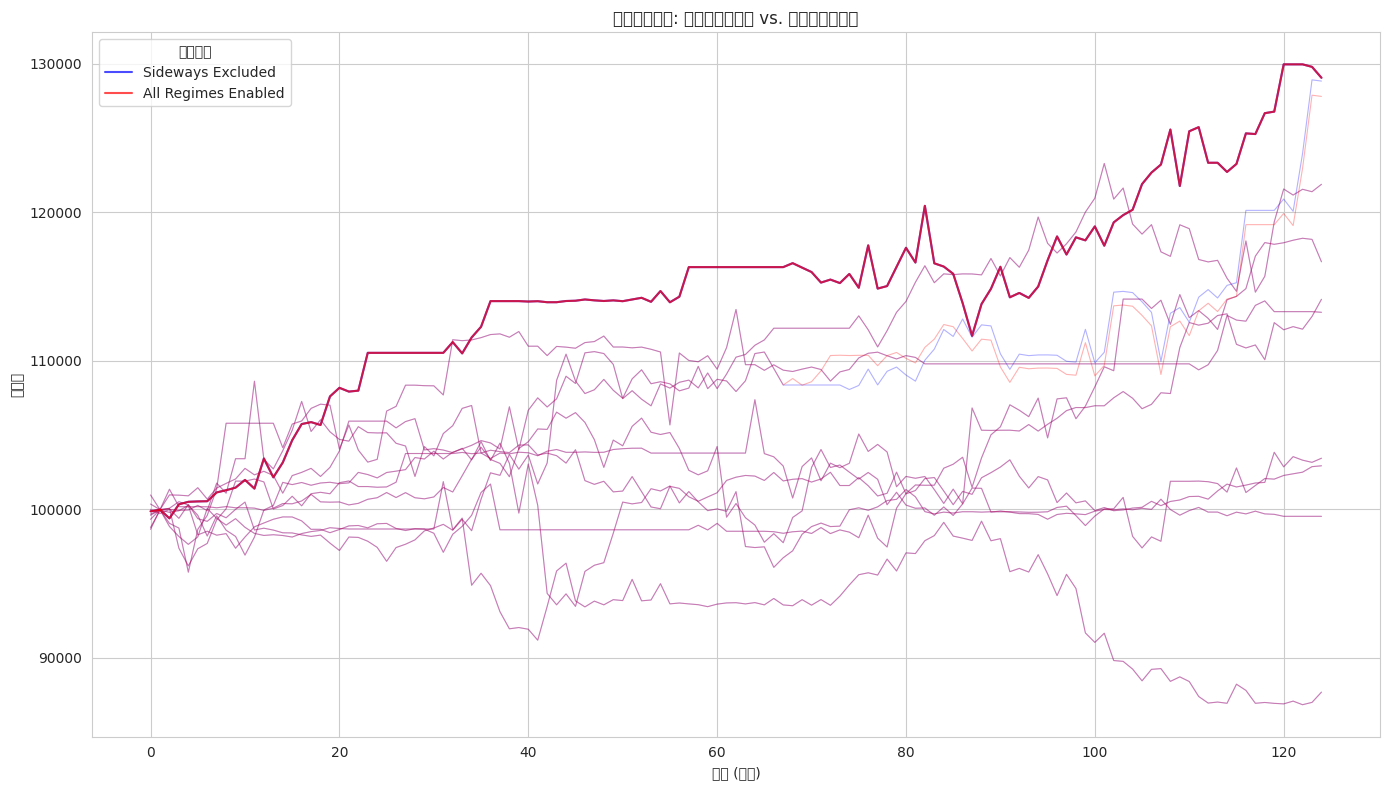


===== Summary Comparison of Average CV Metrics === ==


,Sharpe,Max DD,PF,Total Trades,Stability
レンジ相場除外,1.370015,-0.074935,1.374628,18.4,99.657963
全レジーム有効,1.363970,-0.074935,1.373124,18.6,99.738716


In [126]:
import json
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager

# Install and configure japanize_matplotlib for Japanese display
# print("Configuring matplotlib for Japanese display...")
# !pip install japanize-matplotlib -qq
# !sudo apt-get -y install fonts-ipaexfont-gothic fonts-ipaexfont-mincho -qq > /dev/null
# !rm -rf ~/.cache/matplotlib
# import japanize_matplotlib
# japanize_matplotlib.japanize()
# plt.rcParams['axes.unicode_minus'] = False
# plt.rcParams['font.family'] = 'IPAexGothic'
# print("Japanese font configured.")

# BEST_PARAMS_PATHは前のセルで定義されています
try:
    with open(BEST_PARAMS_PATH, "r") as f:
        best_result_data = json.load(f)

    best_score = best_result_data.get("score")
    fold_metrics = best_result_data.get("fold_metrics")
    total_trades_overall = best_result_data.get("total_trades_overall")

    print("\n===== Optuna最適化のベストスコア === ==")
    if best_score is not None:
        print(f"総合スコア: {best_score:.4f}")
    else:
        print("総合スコア: N/A (スコアがJSONファイルに見つかりません)")

    if fold_metrics:
        df_fold_results = pd.DataFrame(fold_metrics)
        print("\n===== ウォークフォワード各フォールドのメトリクス === ==")
        for idx, row_data in df_fold_results.iterrows():
            print(f"  フォールド {idx + 1}:")
            for col, val in row_data.items():
                print(f"    {col}: {val:.4f}")
            print()

        print("\n===== ウォークフォワードメトリクス (平均) === ==")
        mean_metrics = df_fold_results.mean()
        for col, val in mean_metrics.items():
            print(f"  {col}: {val:.4f}")
        print()

        print("\n===== ウォークフォワードメトリクス (標準偏差) === ==")
        std_metrics = df_fold_results[['sharpe', 'total_return', 'pf']].std()
        for col, val in std_metrics.items():
            print(f"  {col}の標準偏差: {val:.4f}")
        print()

        print("\n===== ウォークフォワードメトリクス (その他統計) === ==")
        print(f"  フォールドごとのトレード数の分散: {df_fold_results['total_trades'].var():.4f}")
        print()

        print("\n===== 特定のフォールドの識別 === ==")
        lowest_sharpe_fold = df_fold_results['sharpe'].idxmin()
        lowest_return_fold = df_fold_results['total_return'].idxmin()
        worst_max_dd_fold = df_fold_results['max_dd'].idxmin() # max_ddは負の値なのでidxminが最も悪い値を返す

        print(f"  最低Sharpeのフォールド: フォールド {lowest_sharpe_fold + 1} (Sharpe: {df_fold_results.loc[lowest_sharpe_fold, 'sharpe']:.4f})")
        print(f"  最低Returnのフォールド: フォールド {lowest_return_fold + 1} (Return: {df_fold_results.loc[lowest_return_fold, 'total_return']:.4f}%)者に)")
        print(f"  最大DDが最も悪いフォールド: フォールド {worst_max_dd_fold + 1} (Max DD: {df_fold_results.loc[worst_max_dd_fold, 'max_dd']:.4f})")
        print()

    else:
        print("fold_metricsがbest_params.jsonに見つかりませんでした。Optunaの学習が完了しているか確認してください。")

    if total_trades_overall is not None:
        print(f"\n全フォールドでの総取引回数: {total_trades_overall}")
    else:
        print("\n全フォールドでの総取引回数: N/A (総取引回数がJSONファイルに見つかりません)")

    print("\n===== その他の情報 (現状のデータ構造では表示できません) === ==")
    print("  以下のメトリクスは、`objective`関数や`run_backtest`関数の出力に含める必要があります:")
    print("  - 平均勝ちトレード利益 / 平均負けトレード損失 / Win/Loss Ratio")
    print("  - 各フォールドの期間（年・相場状態） / トレンド期 vs レンジ期の内訳")
    print("  - 平均ホールド期間 / トレード頻度（日あたり）")
    print("  これらの情報を表示するには、OptunaのObjective関数およびBacktest関数を修正し、結果としてこれらの値を保存するようにしてください。")

except FileNotFoundError:
    print(f"エラー: {BEST_PARAMS_PATH} が見つかりません。Optunaの実行を確認してください。")
except Exception as e:
    print(f"エラー発生: {e}")


# --- Japanese Font Configuration ---
print("Configuring matplotlib for Japanese display...")

# Install the japanize_matplotlib package first to make it available for import
print("Installing japanize_matplotlib package...")
!pip install japanize-matplotlib -qq

# Install IPAex Gothic font for broader support (Colab usually handles this smoothly)
print("Installing IPAex Gothic fonts...")
!sudo apt-get -y install fonts-ipaexfont-gothic fonts-ipaexfont-mincho -qq > /dev/null

# Clear matplotlib font cache aggressively by removing the directory
print("Clearing matplotlib font cache...")
!rm -rf ~/.cache/matplotlib
print("matplotlib font cache cleared.")

# Re-import japanize_matplotlib and explicitly call japanize() to apply settings
import japanize_matplotlib # Moved to here after installation
japanize_matplotlib.japanize() # Explicitly call the configuration function
print("japanize_matplotlib re-imported and re-configured.")

# Configure matplotlib for correct minus signs display
plt.rcParams['axes.unicode_minus'] = False # Prevents minus signs from being displayed as squares
# Explicitly set the font family to ensure Japanese characters are displayed correctly.
plt.rcParams['font.family'] = 'IPAexGothic'

# Verify the font family actually being used after japanize_matplotlib's configuration
print(f"matplotlib font family after japanize_matplotlib: {plt.rcParams['font.family']}")
# --- End Japanese Font Configuration ---

# --- Load best parameters ---
# Assuming BEST_PARAMS_PATH (for main study) and BEST_PARAMS_PATH_LIGHT (for light study)
# are defined from previous cells (LUK3w6ls2Gkq and 83340415 respectively).
# You might choose which one to load based on your current optimization stage.

# For plotting the final best results, we usually load from BEST_PARAMS_PATH.
# If you want to plot results from the light study, change this to BEST_PARAMS_PATH_LIGHT
params_to_load_path = BEST_PARAMS_PATH # Use BEST_PARAMS_PATH or BEST_PARAMS_PATH_LIGHT

try:
    with open(params_to_load_path, 'r') as f:
        best_params_data = json.load(f)
    best_model_params = best_params_data['model_params']
    best_strategy_params = best_params_data['strategy_params']
    print(f"Loaded best parameters from {params_to_load_path}")
except FileNotFoundError:
    print(f"Error: {params_to_load_path} not found. Please ensure Optuna optimization has been run.")
    best_model_params = {}
    best_strategy_params = {}
    # Fallback or raise error if parameters are critical
except KeyError as e:
    print(f"Error loading key from {params_to_load_path}: {e}")
    best_model_params = {}
    best_strategy_params = {}

# --- Actual evaluate_strategy_cv function ---
# This function re-runs the backtest with the best parameters across CV folds
def evaluate_strategy_cv(X_full, y_full, df_encoded_full, df_original_full, model_params, strategy_params, exclude_sideways_regime):
    print(f"Evaluating strategy (exclude_sideways_regime={exclude_sideways_regime})")

    # Use the same TimeSeriesSplit setup as in objective/objective_light
    tscv = TimeSeriesSplit(n_splits=10) # Using 10 splits, adjust if objective_light used 5
    equity_curves = []
    trade_logs = []
    results_list = []

    seed = 42 # Ensure consistent seed for reproducibility

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full)):
        X_train_cv, X_test_cv = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train_cv, y_test_cv = y_full.iloc[train_idx], y_full.iloc[test_idx]

        if len(X_test_cv) < 50: # Skip if test set is too small
            continue

        # SMOTE
        smote = SMOTE(random_state=seed)
        X_train_resampled_array, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)
        X_train_res = pd.DataFrame(X_train_resampled_array, columns=X_train_cv.columns, index=y_train_res.index)

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test_cv)

        # Model Training
        model = XGBClassifier(
            **model_params,
            random_state=seed,
            eval_metric='logloss',
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train_res)

        # Prediction
        proba = model.predict_proba(X_test_scaled)[:, 1]
        proba_series = pd.Series(proba, index=X_test_cv.index)

        # Access features directly from df_encoded_full using the test set index.
        df_encoded_test_fold = df_encoded_full.loc[X_test_cv.index]
        df_original_test_fold = df_original_full.loc[X_test_cv.index]

        trend_strength_series = df_encoded_test_fold["TREND_STRENGTH"]
        volatility_series = df_encoded_test_fold["Volatility_Short"]
        momentum_series = df_encoded_test_fold["RET_5"]
        adx_series = df_encoded_test_fold["ADX"]
        atr_series = df_encoded_test_fold["ATR"]
        sma_50_series = df_encoded_test_fold["SMA_50"]
        sma_200_series = df_encoded_test_fold["SMA_200"]
        sma_diff_abs_series = df_encoded_test_fold["SMA_diff_abs"]
        # Check if 'w_vol_expansion' exists in strategy_params and 'Volatility_Expansion_Ratio' in df_encoded_test_fold
        volatility_expansion_ratio_series = df_encoded_test_fold.get("Volatility_Expansion_Ratio", pd.Series(0, index=X_test_cv.index)) # Default to 0 if not present

        # Momentum term adjustment for downtrend
        momentum_term_series = momentum_series.copy()
        market_regime_test_cv_str = pd.Series('', index=X_test_cv.index)
        cond_sideways_cv = (adx_series < strategy_params['adx_sideways_th']) & \
                             (sma_diff_abs_series < strategy_params['trend_strength_sideways_th'])
        market_regime_test_cv_str.loc[cond_sideways_cv] = 'sideways'
        market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series > sma_200_series)] = 'uptrend'
        market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series <= sma_200_series)] = 'downtrend'

        is_downtrend_regime = (market_regime_test_cv_str == 'downtrend')
        if 'downtrend_momentum_penalty_factor' in strategy_params: # Check if this param exists
            momentum_term_series[is_downtrend_regime] *= strategy_params['downtrend_momentum_penalty_factor']

        # Calculate Entry Score
        entry_score_series = (
            proba_series
            + strategy_params['w_trend'] * trend_strength_series.abs()
            + strategy_params['w_mom'] * momentum_term_series
            - strategy_params['w_vol'] * volatility_series
        )
        if 'w_vol_expansion' in strategy_params: # Only add if the parameter exists
             entry_score_series += strategy_params['w_vol_expansion'] * volatility_expansion_ratio_series

        # Trend Filter
        adx_ma = adx_series.rolling(20, min_periods=1).mean()
        adx_slope = adx_series.diff()
        adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

        use_slope = strategy_params.get('use_slope', False) # Default to False if not in params
        cond_trend = (
            (adx_ma > strategy_params['adx_th']) &
            (trend_strength_series.abs() > strategy_params['trend_strength_min_abs'])
        )
        if use_slope:
            cond_trend = cond_trend & (adx_slope_mean > 0)

        # Proba Filter
        adjusted_proba_th_arr = np.full(len(proba_series), strategy_params['proba_th'])

        proba_filter_type = strategy_params.get('proba_filter_type', 'threshold') # Default to threshold

        if proba_filter_type == 'threshold':
            is_uptrend = (market_regime_test_cv_str == 'uptrend').values
            adjusted_proba_th_arr = np.where(is_uptrend, strategy_params['proba_th'] + strategy_params.get('proba_th_uptrend_adj', 0.0), adjusted_proba_th_arr)
            is_downtrend = (market_regime_test_cv_str == 'downtrend').values
            adjusted_proba_th_arr = np.where(is_downtrend, strategy_params['proba_th'] + strategy_params.get('proba_th_downtrend_adj', 0.0), adjusted_proba_th_arr)
            is_sideways = (market_regime_test_cv_str == 'sideways').values
            adjusted_proba_th_arr = np.where(is_sideways, strategy_params['proba_th'] + strategy_params.get('proba_th_sideways_adj', 0.0), adjusted_proba_th_arr)

            # ADX high/low adjustments
            is_adx_high = (adx_series > strategy_params.get('adx_high_th', 25.0)).values
            adjusted_proba_th_arr = np.where(is_adx_high, adjusted_proba_th_arr + strategy_params.get('adx_high_proba_adj', 0.0), adjusted_proba_th_arr)

            is_adx_low = (adx_series < strategy_params.get('adx_low_th', 20.0)).values
            adjusted_proba_th_arr = np.where(is_adx_low, adjusted_proba_th_arr + strategy_params.get('adx_low_proba_adj', 0.0), adjusted_proba_th_arr)

            cond_proba = proba_series > adjusted_proba_th_arr
        else: # 'quantile'
            cond_proba = proba_series > proba_series.quantile(strategy_params['proba_th'])

        # ATR Volatility Filter
        atr_ma = atr_series.rolling(window=20, min_periods=1).mean()
        volatility_ratio = atr_series / (atr_ma + 1e-9)
        cond_volatility_filter = (volatility_ratio <= strategy_params.get('volatility_filter_threshold', 1.5))

        base_signal = cond_trend & cond_proba & cond_volatility_filter

        # Determine position size
        signal_multipliers = pd.Series(0.0, index=X_test_cv.index)
        if not entry_score_series.loc[base_signal].empty:
            strength_on_signal_days = entry_score_series.loc[base_signal].rank(pct=True)
            base_size = pd.Series(strategy_params.get('conservative_size', 1.0), index=X_test_cv.index)

            if 'trend_strength_regime_th' in strategy_params: # Only apply if param exists
                aggressive_mask_days = (trend_strength_series.abs() > strategy_params['trend_strength_regime_th'])
                base_size[aggressive_mask_days] = strategy_params.get('aggressive_size', 1.5)

            signal_multipliers.loc[base_signal] = strength_on_signal_days * base_size.loc[base_signal]

        # Low Trend Strength Cut-off
        if 'low_trend_strength_cut_off_th' in strategy_params: # Only apply if param exists
            cut_off_mask = (trend_strength_series.abs() < strategy_params['low_trend_strength_cut_off_th'])
            signal_multipliers[cut_off_mask] = 0.0

        # Exclude signals during sideways regime if requested
        if exclude_sideways_regime: # Use the parameter passed to this function
            sideways_regime_mask = (market_regime_test_cv_str == 'sideways')
            signal_multipliers[sideways_regime_mask] = 0.0

        df_trade_info_fold_data = {
            'proba': proba_series,
            'entry_score': entry_score_series,
            'Market_Regime': market_regime_test_cv_str
        }
        df_trade_info_fold = pd.DataFrame(df_trade_info_fold_data)

        # Backtest (using the run_backtest function)
        from __main__ import run_backtest, calc_metrics # Import from global scope
        results, equity_curve, _, trade_log_fold = run_backtest(
            df_original_test_fold,
            X_test_cv,
            signal_multipliers,
            df_trade_info_fold,
            atr_sl_multiplier_uptrend=strategy_params.get('atr_sl_multiplier_uptrend', 1.2),
            atr_sl_multiplier_downtrend=strategy_params.get('atr_sl_multiplier_downtrend', 1.2),
            atr_sl_multiplier_sideways=strategy_params.get('atr_sl_multiplier_sideways', 1.0),
            trail_ratio=strategy_params.get('trail_ratio', 0.5),
            min_hold_bars=strategy_params.get('min_hold_bars', 1),
            max_hold_bars=strategy_params.get('max_hold_bars', 10),
            atr_tp_multiplier=strategy_params.get('atr_tp_multiplier', 2.5),
            profit_take_threshold_atr_multiplier=strategy_params.get('profit_take_threshold_atr_multiplier', 2.0),
            graduated_trail_ratio=strategy_params.get('graduated_trail_ratio', 0.3),
            partial_profit_take_ratio=strategy_params.get('partial_profit_take_ratio', 0.0)
        )

        # Calculate metrics from equity curve for stability
        metrics_from_equity = calc_metrics(equity_curve)
        results['Stability'] = metrics_from_equity.get('Stability', 0.0) # Add stability to results

        if len(equity_curve) > 0:
            equity_curves.append(equity_curve)
            trade_logs.append(trade_log_fold)
            results_list.append(results)

    return pd.DataFrame(results_list) if results_list else pd.DataFrame(), equity_curves, trade_logs

scenarios_to_display = {
    'レンジ相場除外': {
        'exclude_sideways_regime': True,
        'plot_label': 'Sideways Excluded',
        'color': 'blue'
    },
    '全レジーム有効': {
        'exclude_sideways_regime': False,
        'plot_label': 'All Regimes Enabled',
        'color': 'red'
    }
}

# Assuming X, y, df_encoded, df are defined from previous cells.
# Ensure they are available in the global scope.

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

print("\n===== Cross-Validation Performance Comparison === ==")

all_scenario_metrics = {}

for scenario_name, scenario_params in scenarios_to_display.items():
    print(f"\n--- Scenario: {scenario_name} ---")
    results_df, equity_curves_for_plotting, _ = evaluate_strategy_cv(
        X, y, df_encoded, df, best_model_params, best_strategy_params,
        exclude_sideways_regime=scenario_params["exclude_sideways_regime"]
    )

    if not results_df.empty:
        mean_metrics = results_df.mean()
        all_scenario_metrics[scenario_name] = mean_metrics

        print("Average CV Metrics:")
        print(f"  Sharpe Ratio: {mean_metrics['Sharpe']:.4f}")
        print(f"  Total Return: {mean_metrics['Total Return']:.2f}%")
        print(f"  Max Drawdown: {mean_metrics['Max DD']:.4f}")
        print(f"  Profit Factor: {mean_metrics['PF']:.4f}")
        print(f"  Win Rate (%): {mean_metrics['Win Rate (%)']:.2f}%")
        print(f"  Total Trades (avg per fold): {mean_metrics['Total Trades']:.2f}")
        print(f"  Total Trades (overall): {results_df['Total Trades'].sum()}")
        print(f"  Stability: {mean_metrics['Stability']:.4f}") # Display Stability

        # Plotting equity curves for the current scenario
        for i, equity_curve_data in enumerate(equity_curves_for_plotting):
            equity_curve_series = pd.Series(equity_curve_data)
            # Only add label to the first curve of each scenario to avoid clutter
            if i == 0:
                equity_curve_series.plot(label=f'{scenario_params["plot_label"]}', color=scenario_params['color'], alpha=0.7)
            else:
                equity_curve_series.plot(color=scenario_params['color'], alpha=0.3, linewidth=0.8)

    else:
        print(f"警告: シナリオ '{scenario_name}' の結果が見つかりませんでした。")

plt.title('累積損益曲線: レンジ相場除外 vs. 全レジーム有効') # Title with Japanese characters
plt.xlabel('期間 (日数)') # X-label indicating numerical periods
plt.ylabel('純資産') # Y-label with Japanese characters
plt.legend(title='シナリオ') # Legend title with Japanese characters
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n===== Summary Comparison of Average CV Metrics === ==")
if all_scenario_metrics:
    summary_df = pd.DataFrame(all_scenario_metrics).T
    display(summary_df[['Sharpe', 'Max DD', 'PF', 'Total Trades', 'Stability']]) # Modified to display stability
else:
    print("No scenario metrics to compare.")

### アウトオブサンプル（OOS）検証

In [127]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
import os

# Load best parameters from the Optuna results
# Assuming BEST_PARAMS_PATH is defined in a previous cell (e.g., LUK3w6ls2Gkq)
try:
    with open(BEST_PARAMS_PATH, 'r') as f:
        best_params_data = json.load(f)
    best_model_params = best_params_data['model_params']
    best_strategy_params = best_params_data['strategy_params']
    print(f"Loaded best parameters from {BEST_PARAMS_PATH}")
except FileNotFoundError:
    print(f"Error: {BEST_PARAMS_PATH} not found. Please ensure Optuna optimization has been run.")
    # Fallback to empty dicts or raise an error if parameters are critical
    best_model_params = {}
    best_strategy_params = {}
except KeyError as e:
    print(f"Error loading key from {BEST_PARAMS_PATH}: {e}")
    best_model_params = {}
    best_strategy_params = {}

# OOS Split Date
oos_start_date = pd.Timestamp('2024-01-01')

# --- データ分割: In-sample (Train) と OOS ---
# In-sampleデータ（OOS開始日以前）
X_train_final = X[X.index < oos_start_date].copy()
y_train_final = y[y.index < oos_start_date].copy()
df_encoded_train_final = df_encoded[df_encoded.index < oos_start_date].copy()
df_original_train_final = df[df.index < oos_start_date].copy()

# OOSデータ（OOS開始日以降）
X_oos = X[X.index >= oos_start_date].copy()
y_oos = y[y.index >= oos_start_date].copy()
df_encoded_oos = df_encoded[df_encoded.index >= oos_start_date].copy()
df_original_oos = df[df.index >= oos_start_date].copy()

print(f"In-sample データ期間: {X_train_final.index.min().strftime('%Y-%m-%d')} to {X_train_final.index.max().strftime('%Y-%m-%d')} (Shape: {X_train_final.shape})")
print(f"OOS データ期間: {X_oos.index.min().strftime('%Y-%m-%d')} to {X_oos.index.max().strftime('%Y-%m-%d')} (Shape: {X_oos.shape})")

# OOSデータが存在しない場合のチェック
if X_oos.empty:
    raise ValueError("OOSデータが見つかりません。'oos_start_date'と入力データを確認してください。")

# --- スケーラーの学習と適用 ---
# スケーラーはin-sampleデータのみで学習し、in-sampleとOOSの両方に適用
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_oos_scaled = scaler.transform(X_oos)

# DataFrameに戻す
X_train_final_scaled_df = pd.DataFrame(X_train_final_scaled, columns=X_train_final.columns, index=X_train_final.index)
X_oos_scaled_df = pd.DataFrame(X_oos_scaled, columns=X_oos.columns, index=X_oos.index)

# --- SMOTEをin-sample訓練データに適用 ---
smote = SMOTE(random_state=42)
X_train_resampled_array, y_train_res = smote.fit_resample(X_train_final_scaled_df, y_train_final)
X_train_res = pd.DataFrame(X_train_resampled_array, columns=X_train_final_scaled_df.columns, index=y_train_res.index)

# --- 最終モデルの学習 (in-sampleデータ全体) ---
model = XGBClassifier(
    **best_model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)

# --- OOSシグナルの生成 ---
proba_oos = model.predict_proba(X_oos_scaled_df)[:, 1]
proba_series_oos = pd.Series(proba_oos, index=X_oos.index)

# OOSデータから特徴量を再構築（既存のストラテジーロジックを適用）
trend_strength_series_oos = df_encoded_oos["TREND_STRENGTH"]
volatility_series_oos = df_encoded_oos["Volatility_Short"]
momentum_series_oos = df_encoded_oos["RET_5"]
adx_series_oos = df_encoded_oos["ADX"]
atr_series_oos = df_encoded_oos["ATR"]
sma_50_series_oos = df_encoded_oos["SMA_50"]
sma_200_series_oos = df_encoded_oos["SMA_200"]
sma_diff_abs_series_oos = df_encoded_oos["SMA_diff_abs"]
volatility_expansion_ratio_series_oos = df_encoded_oos.get("Volatility_Expansion_Ratio", pd.Series(0, index=X_oos.index))

# トレンドレジームのモーメンタム調整
momentum_term_series_oos = momentum_series_oos.copy()
market_regime_oos_str = pd.Series('', index=X_oos.index)
cond_sideways_oos = (adx_series_oos < best_strategy_params['adx_sideways_th']) | \
                    (sma_diff_abs_series_oos < best_strategy_params['trend_strength_sideways_th'])
market_regime_oos_str.loc[cond_sideways_oos] = 'sideways'
market_regime_oos_str.loc[~cond_sideways_oos & (sma_50_series_oos > sma_200_series_oos)] = 'uptrend'
market_regime_oos_str.loc[~cond_sideways_oos & (sma_50_series_oos <= sma_200_series_oos)] = 'downtrend'

is_downtrend_regime_oos = (market_regime_oos_str == 'downtrend')
if 'downtrend_momentum_penalty_factor' in best_strategy_params:
    momentum_term_series_oos[is_downtrend_regime_oos] *= best_strategy_params['downtrend_momentum_penalty_factor']

# エントリースコアの計算
entry_score_series_oos = (
    proba_series_oos
    + best_strategy_params['w_trend'] * trend_strength_series_oos.abs()
    + best_strategy_params['w_mom'] * momentum_term_series_oos
    - best_strategy_params['w_vol'] * volatility_series_oos
)
if 'w_vol_expansion' in best_strategy_params:
     entry_score_series_oos += best_strategy_params['w_vol_expansion'] * volatility_expansion_ratio_series_oos

# トレンドフィルター
adx_ma_oos = adx_series_oos.rolling(20, min_periods=1).mean()
adx_slope_oos = adx_series_oos.diff()
adx_slope_mean_oos = adx_slope_oos.rolling(5, min_periods=1).mean()

use_slope_oos = best_strategy_params.get('use_slope', False)
cond_trend_oos = (
    (adx_ma_oos > best_strategy_params['adx_th']) &
    (trend_strength_series_oos.abs() > best_strategy_params['trend_strength_min_abs'])
)
if use_slope_oos:
    cond_trend_oos = cond_trend_oos & (adx_slope_mean_oos > 0)

# 確率フィルター
adjusted_proba_th_arr_oos = np.full(len(proba_series_oos), best_strategy_params['proba_th'])

proba_filter_type_oos = best_strategy_params.get('proba_filter_type', 'threshold')

if proba_filter_type_oos == 'threshold':
    is_uptrend_oos = (market_regime_oos_str == 'uptrend').values
    adjusted_proba_th_arr_oos = np.where(is_uptrend_oos, best_strategy_params['proba_th'] + best_strategy_params.get('proba_th_uptrend_adj', 0.0), adjusted_proba_th_arr_oos)
    is_downtrend_oos = (market_regime_oos_str == 'downtrend').values
    adjusted_proba_th_arr_oos = np.where(is_downtrend_oos, best_strategy_params['proba_th'] + best_strategy_params.get('proba_th_downtrend_adj', 0.0), adjusted_proba_th_arr_oos)
    is_sideways_oos = (market_regime_oos_str == 'sideways').values
    adjusted_proba_th_arr_oos = np.where(is_sideways_oos, best_strategy_params['proba_th'] + best_strategy_params.get('proba_th_sideways_adj', 0.0), adjusted_proba_th_arr_oos)

    is_adx_high_oos = (adx_series_oos > best_strategy_params.get('adx_high_th', 25.0)).values
    adjusted_proba_th_arr_oos = np.where(is_adx_high_oos, adjusted_proba_th_arr_oos + best_strategy_params.get('adx_high_proba_adj', 0.0), adjusted_proba_th_arr_oos)

    is_adx_low_oos = (adx_series_oos < best_strategy_params.get('adx_low_th', 20.0)).values
    adjusted_proba_th_arr_oos = np.where(is_adx_low_oos, adjusted_proba_th_arr_oos + best_strategy_params.get('adx_low_proba_adj', 0.0), adjusted_proba_th_arr_oos)

    cond_proba_oos = proba_series_oos > adjusted_proba_th_arr_oos
else: # 'quantile'
    cond_proba_oos = proba_series_oos > proba_series_oos.quantile(best_strategy_params['proba_th'])

# ATRボラティリティフィルター
atr_ma_oos = atr_series_oos.rolling(window=20, min_periods=1).mean()
volatility_ratio_oos = atr_series_oos / (atr_ma_oos + 1e-9)
cond_volatility_filter_oos = (volatility_ratio_oos <= best_strategy_params.get('volatility_filter_threshold', 1.5))

base_signal_oos = cond_trend_oos & cond_proba_oos & cond_volatility_filter_oos

# ポジションサイズを決定
signal_multipliers_oos = pd.Series(0.0, index=X_oos.index)
if not entry_score_series_oos.loc[base_signal_oos].empty:
    strength_on_signal_days_oos = entry_score_series_oos.loc[base_signal_oos].rank(pct=True)
    base_size_oos = pd.Series(best_strategy_params.get('conservative_size', 1.0), index=X_oos.index)

    if 'trend_strength_regime_th' in best_strategy_params:
        aggressive_mask_days_oos = (trend_strength_series_oos.abs() > best_strategy_params['trend_strength_regime_th'])
        base_size_oos[aggressive_mask_days_oos] = best_strategy_params.get('aggressive_size', 1.5)

    signal_multipliers_oos.loc[base_signal_oos] = strength_on_signal_days_oos * base_size_oos.loc[base_signal_oos]

# 低トレンド強度によるカットオフ
if 'low_trend_strength_cut_off_th' in best_strategy_params:
    cut_off_mask_oos = (trend_strength_series_oos.abs() < best_strategy_params['low_trend_strength_cut_off_th'])
    signal_multipliers_oos[cut_off_mask_oos] = 0.0

# レンジ相場でのシグナル除外
if best_strategy_params.get('exclude_sideways_regime', False):
    sideways_regime_mask_oos = (market_regime_oos_str == 'sideways')
    signal_multipliers_oos[sideways_regime_mask_oos] = 0.0

# OOS用のdf_trade_infoを作成
df_trade_info_oos_data = {
    'proba': proba_series_oos,
    'entry_score': entry_score_series_oos,
    'Market_Regime': market_regime_oos_str
}
df_trade_info_oos = pd.DataFrame(df_trade_info_oos_data)

# --- OOSバックテストの実行 ---
from __main__ import run_backtest # run_backtest関数がグローバルスコープで利用可能であることを確認

oos_results, oos_equity_curve, _, oos_trade_log = run_backtest( # Modified to capture oos_trade_log
    df_original_oos,
    X_oos,
    signal_multipliers_oos,
    df_trade_info_oos,
    atr_sl_multiplier_uptrend=best_strategy_params.get('atr_sl_multiplier_uptrend', 1.2),
    atr_sl_multiplier_downtrend=best_strategy_params.get('atr_sl_multiplier_downtrend', 1.2),
    atr_sl_multiplier_sideways=best_strategy_params.get('atr_sl_multiplier_sideways', 1.0),
    trail_ratio=best_strategy_params.get('trail_ratio', 0.5),
    min_hold_bars=best_strategy_params.get('min_hold_bars', 1),
    max_hold_bars=best_strategy_params.get('max_hold_bars', 10),
    atr_tp_multiplier=best_strategy_params.get('atr_tp_multiplier', 2.5),
    profit_take_threshold_atr_multiplier=best_strategy_params.get('profit_take_threshold_atr_multiplier', 2.0),
    graduated_trail_ratio=best_strategy_params.get('graduated_trail_ratio', 0.3),
    partial_profit_take_ratio=best_strategy_params.get('partial_profit_take_ratio', 0.0)
)

# --- OOS結果の表示 ---
print("\n===== OOS RESULT === ==")
print(f"Sharpe: {oos_results.get('Sharpe', 0.0):.4f}")
print(f"Total Return: {oos_results.get('Total Return', 0.0):.2f}%")
print(f"Max DD: {oos_results.get('Max DD', 0.0):.4f}")
print(f"PF: {oos_results.get('PF', 0.0):.4f}")
print(f"Win Rate: {oos_results.get('Win Rate (%)', 0.0):.2f}%")
print(f"Trades: {oos_results.get('Total Trades', 0)}")

# --- CV平均結果の取得と比較表示 ---
# df_fold_resultsが前のセルで計算され、best_params.jsonに保存されていることを前提とします。
# b4389337セルでbest_result_dataから`fold_metrics`を読み込んでdf_fold_resultsに格納しているため、ここではそれを再利用します。
# もしdf_fold_resultsが定義されていない場合は、best_params_dataから直接読み込みます。

cv_avg_sharpe = 0.0
cv_avg_return = 0.0
cv_avg_pf = 0.0
cv_avg_win_rate = 0.0
cv_avg_max_dd = 0.0
cv_total_trades = 0

# best_result_dataはLUK3w6ls2Gkqで読み込まれ、OsXQ4rGEkh0_でも使用されています
# fold_metricsはbest_result_data['fold_metrics']に格納されていると仮定
if best_params_data and best_params_data.get("fold_metrics"):
    df_fold_results = pd.DataFrame(best_params_data["fold_metrics"])
    cv_avg_sharpe = df_fold_results['sharpe'].mean()
    cv_avg_return = df_fold_results['total_return'].mean()
    cv_avg_pf = df_fold_results['pf'].mean()
    cv_avg_win_rate = df_fold_results['win_rate'].mean()
    cv_avg_max_dd = df_fold_results['max_dd'].mean()
    cv_total_trades = df_fold_results['total_trades'].sum() # 全CVフォールドの合計取引数

    print("\n===== COMPARISON === ==")
    print(f"CV Sharpe ({cv_avg_sharpe:.4f}) vs OOS Sharpe ({oos_results.get('Sharpe', 0.0):.4f})")
    print(f"CV Return ({cv_avg_return:.2f}%) vs OOS Return ({oos_results.get('Total Return', 0.0):.2f}%)")
    print(f"CV Max DD ({cv_avg_max_dd:.4f}) vs OOS Max DD ({oos_results.get('Max DD', 0.0):.4f})")
    print(f"CV PF ({cv_avg_pf:.4f}) vs OOS PF ({oos_results.get('PF', 0.0):.4f})")
    print(f"CV Win Rate ({cv_avg_win_rate:.2f}%) vs OOS Win Rate ({oos_results.get('Win Rate (%)', 0.0):.2f}%)者に)")
    print(f"CV Total Trades ({cv_total_trades}) vs OOS Trades ({oos_results.get('Total Trades', 0)})")
else:
    print("\n===== COMPARISON === ==")
    print("CV結果が比較のために利用できません。CVメトリクスを生成する前のセルが実行されていることを確認してください。")

Loaded best parameters from /content/drive/MyDrive/optuna_trading/best_params.json
In-sample データ期間: 2020-11-23 to 2023-12-29 (Shape: (780, 24))
OOS データ期間: 2024-01-02 to 2026-06-05 (Shape: (609, 24))

===== OOS RESULT === ==
Sharpe: 1.2545
Total Return: 63.86%
Max DD: -0.1546
PF: 1.3132
Win Rate: 45.57%
Trades: 79

===== COMPARISON === ==
CV Sharpe (1.3906) vs OOS Sharpe (1.2545)
CV Return (12.04%) vs OOS Return (63.86%)
CV Max DD (-0.0766) vs OOS Max DD (-0.1546)
CV PF (1.3758) vs OOS PF (1.3132)
CV Win Rate (47.52%) vs OOS Win Rate (45.57%)者に)
CV Total Trades (186) vs OOS Trades (79)


In [128]:
import pandas as pd
import numpy as np

# Helper function definitions to ensure they are globally available for analysis
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()

# Convert oos_trade_log to a DataFrame for easier manipulation in analysis cells
# This also ensures 'trade_return_pct' is properly accessed.
if 'oos_trade_log' in globals() and oos_trade_log:
    df_regime_trades = pd.DataFrame(oos_trade_log)

    # Ensure numerical types and boolean for 'win'
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'])
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)
    df_regime_trades['trade_return_pct'] = pd.to_numeric(df_regime_trades['trade_return_pct'])

    print("df_regime_trades created and helper functions defined.")
else:
    print("Error: oos_trade_log not found or is empty. Please ensure OOS backtest was run.")

df_regime_trades created and helper functions defined.


In [129]:
import pandas as pd

# Define the OOS period as requested by the user
oos_start_date_user = pd.Timestamp('2024-01-02')
oos_end_date_user = pd.Timestamp('2026-05-21')

# Filter df_original_oos to match the user's requested OOS period
df_oos_filtered = df_original_oos[(df_original_oos.index >= oos_start_date_user) & (df_original_oos.index <= oos_end_date_user)].copy()

# Calculate Buy & Hold return for the filtered OOS period
if not df_oos_filtered.empty:
    buy_hold_start_price = df_oos_filtered['Close'].iloc[0]
    buy_hold_end_price = df_oos_filtered['Close'].iloc[-1]
    buy_hold_return_oos = ((buy_hold_end_price / buy_hold_start_price) - 1) * 100
else:
    buy_hold_return_oos = 0.0
    print("Warning: No data available for the specified OOS Buy & Hold period.")

# Get the Strategy Return from the previously calculated oos_results
strategy_return_oos = oos_results.get('Total Return', 0.0)

# Calculate Alpha (Excess Return)
alpha = strategy_return_oos - buy_hold_return_oos

# Create a comparison table
comparison_data = {
    'Metric': ['Strategy Return', 'Buy & Hold Return', 'Alpha (Excess Return)']
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df['Value (%)'] = [
    f"{strategy_return_oos:.2f}",
    f"{buy_hold_return_oos:.2f}",
    f"{alpha:.2f}"
]

print("\n===== OOS Period Performance Comparison === ==")
display(comparison_df)



===== OOS Period Performance Comparison === ==


,Metric,Value (%)
0,Strategy Return,63.86
1,Buy & Hold Return,79.66
2,Alpha (Excess Return),-15.81


In [130]:
import pandas as pd
import numpy as np

# Helper functions (re-defining or ensuring scope to avoid issues)
def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_equity_curve(equity_curve):
    if equity_curve.empty or len(equity_curve) < 2:
        return np.nan
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()


# --- 1. User-specified OOS period ---
oos_start_date_user = pd.Timestamp('2024-01-02')
oos_end_date_user = pd.Timestamp('2026-05-21')
initial_balance = 100000 # Consistent initial balance

# Filter df_original_oos to match the user's requested OOS period for Buy & Hold
df_exact_oos_period = df_original_oos[(df_original_oos.index >= oos_start_date_user) & (df_original_oos.index <= oos_end_date_user)].copy()

if df_exact_oos_period.empty:
    print("Warning: No data available for the specified OOS Buy & Hold period.")
    buy_hold_sharpe_oos = np.nan
    buy_hold_max_dd_oos = np.nan
    buy_hold_cagr_oos = np.nan
    buy_hold_return_percent_oos = np.nan
else:
    # Calculate Buy & Hold Daily Returns
    buy_hold_daily_returns = df_exact_oos_period['Close'].pct_change().dropna()

    # Calculate Buy & Hold Equity Curve
    bh_equity_curve = (1 + buy_hold_daily_returns).cumprod() * initial_balance

    # Calculate Buy & Hold Sharpe Ratio
    buy_hold_sharpe_oos = calculate_sharpe_ratio(buy_hold_daily_returns)

    # Calculate Buy & Hold Max Drawdown
    buy_hold_max_dd_oos = calculate_max_dd_from_equity_curve(bh_equity_curve)

    # Calculate Buy & Hold Total Return and CAGR
    buy_hold_start_price = df_exact_oos_period['Close'].iloc[0]
    buy_hold_end_price = df_exact_oos_period['Close'].iloc[-1]
    buy_hold_return_percent_oos = ((buy_hold_end_price / buy_hold_start_price) - 1) * 100

    num_days = (oos_end_date_user - oos_start_date_user).days
    if num_days > 0:
        num_years = num_days / 365.25
        buy_hold_cagr_oos = ((buy_hold_end_price / buy_hold_start_price)**(1/num_years) - 1) * 100
    else:
        buy_hold_cagr_oos = 0.0


# --- 2. Re-evaluate Strategy for the exact user-specified OOS period ---
# Filter X_oos, df_trade_info_oos, and signal_multipliers_oos to the exact period
X_oos_exact = X_oos[(X_oos.index >= oos_start_date_user) & (X_oos.index <= oos_end_date_user)].copy()
df_original_oos_exact = df_original_oos[(df_original_oos.index >= oos_start_date_user) & (df_original_oos.index <= oos_end_date_user)].copy()
df_trade_info_oos_exact = df_trade_info_oos[(df_trade_info_oos.index >= oos_start_date_user) & (df_trade_info_oos.index <= oos_end_date_user)].copy()
signal_multipliers_oos_exact = signal_multipliers_oos[(signal_multipliers_oos.index >= oos_start_date_user) & (signal_multipliers_oos.index <= oos_end_date_user)].copy()

if X_oos_exact.empty:
    print("Warning: No strategy data available for the specified OOS period.")
    strategy_sharpe_exact_oos = np.nan
    strategy_max_dd_exact_oos = np.nan
    strategy_return_exact_oos = np.nan
    strategy_cagr_exact_oos = np.nan
else:
    # Run backtest with exact OOS period
    exact_oos_results, exact_oos_equity_curve, _, _ = run_backtest(
        df_original_oos_exact,
        X_oos_exact,
        signal_multipliers_oos_exact,
        df_trade_info_oos_exact,
        atr_sl_multiplier_uptrend=best_strategy_params.get('atr_sl_multiplier_uptrend', 1.2),
        atr_sl_multiplier_downtrend=best_strategy_params.get('atr_sl_multiplier_downtrend', 1.2),
        atr_sl_multiplier_sideways=best_strategy_params.get('atr_sl_multiplier_sideways', 1.0),
        trail_ratio=best_strategy_params.get('trail_ratio', 0.5),
        min_hold_bars=best_strategy_params.get('min_hold_bars', 1),
        max_hold_bars=best_strategy_params.get('max_hold_bars', 10),
        atr_tp_multiplier=best_strategy_params.get('atr_tp_multiplier', 2.5),
        profit_take_threshold_atr_multiplier=best_strategy_params.get('profit_take_threshold_atr_multiplier', 2.0),
        graduated_trail_ratio=best_strategy_params.get('graduated_trail_ratio', 0.3),
        partial_profit_take_ratio=best_strategy_params.get('partial_profit_take_ratio', 0.0)
    )

    strategy_sharpe_exact_oos = exact_oos_results.get('Sharpe', np.nan)
    strategy_max_dd_exact_oos = exact_oos_results.get('Max DD', np.nan)
    strategy_return_exact_oos = exact_oos_results.get('Total Return', np.nan)

    # Calculate CAGR for strategy (using its total return over the period)
    if num_days > 0:
        # Convert total return % to a multiplier (e.g., 43.09% -> 1.4309)
        total_return_multiplier = (strategy_return_exact_oos / 100) + 1
        strategy_cagr_exact_oos = (total_return_multiplier**(1/num_years) - 1) * 100
    else:
        strategy_cagr_exact_oos = 0.0


# --- 3. Create Comparison Table ---
alpha_return = strategy_return_exact_oos - buy_hold_return_percent_oos

comparison_data = {
    'Metric': [
        'Strategy Total Return',
        'Buy & Hold Total Return',
        'Alpha (Excess Return)',
        'Strategy Sharpe Ratio',
        'Buy & Hold Sharpe Ratio',
        'Strategy Max Drawdown',
        'Buy & Hold Max Drawdown',
        'Strategy CAGR',
        'Buy & Hold CAGR'
    ],
    'Value': [
        strategy_return_exact_oos,
        buy_hold_return_percent_oos,
        alpha_return,
        strategy_sharpe_exact_oos,
        buy_hold_sharpe_oos,
        strategy_max_dd_exact_oos,
        buy_hold_max_dd_oos,
        strategy_cagr_exact_oos,
        buy_hold_cagr_oos
    ]
}
comparison_df = pd.DataFrame(comparison_data)

# Format for display
comparison_df['Value'] = comparison_df['Value'].apply(lambda x: f'{x:.2f}%' if '%' in comparison_df.loc[comparison_df['Value'] == x, 'Metric'].iloc[0] else f'{x:.4f}')
# Special formatting for Max Drawdown to show negative sign for percentages
comparison_df.loc[comparison_df['Metric'].str.contains('Max Drawdown'), 'Value'] = comparison_df.loc[comparison_df['Metric'].str.contains('Max Drawdown'), 'Value'].apply(lambda x: f'{float(x.strip("%")):.4f}')

print("\n===== OOS Period Performance Comparison (2024-01-02 to 2026-05-21) =====")
display(comparison_df)


===== OOS Period Performance Comparison (2024-01-02 to 2026-05-21) =====


,Metric,Value
0,Strategy Total Return,59.2622
1,Buy & Hold Total Return,79.6647
2,Alpha (Excess Return),-20.4025
3,Strategy Sharpe Ratio,1.1993
4,Buy & Hold Sharpe Ratio,1.3055
5,Strategy Max Drawdown,-0.1546
6,Buy & Hold Max Drawdown,-0.2277
7,Strategy CAGR,21.5773
8,Buy & Hold CAGR,27.8882


In [131]:
import pandas as pd
import numpy as np

# Helper functions (moved here to avoid ImportError)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    # Assuming daily returns for 252 trading days for annualization
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    # Build a conceptual equity curve from trade PnLs
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9) # Use (peak + 1e-9) to avoid division by zero
    return dd.min()

# Convert oos_trade_log to a DataFrame for easier manipulation
if 'oos_trade_log' in globals() and oos_trade_log:
    df_regime_trades = pd.DataFrame(oos_trade_log)

    # Ensure numerical types and boolean for 'win'
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'])
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)
    df_regime_trades['trade_return_pct'] = pd.to_numeric(df_regime_trades['trade_return_pct'])

    # Group by Market_Regime and calculate aggregated metrics
    # Calculate basic metrics first
    regime_analysis = df_regime_trades.groupby('market_regime').agg(
        Total_Trades=('pnl', 'size'),
        Win_Rate=('win', lambda x: x.mean() * 100), # Percentage
        Average_PnL=('pnl', 'mean'),
        Total_PnL=('pnl', 'sum')
    ).reset_index()

    # Apply custom aggregations using the imported helper functions
    # Initialize columns to avoid KeyError if a regime is missing
    regime_analysis['Profit_Factor'] = np.nan
    regime_analysis['Sharpe_Ratio'] = np.nan
    regime_analysis['Max_Drawdown'] = np.nan

    for index, row in regime_analysis.iterrows():
        regime = row['market_regime']
        d = df_regime_trades[df_regime_trades['market_regime'] == regime]

        if not d.empty:
            regime_analysis.loc[index, 'Profit_Factor'] = calculate_profit_factor(d['pnl'])
            regime_analysis.loc[index, 'Sharpe_Ratio'] = calculate_sharpe_ratio(d['trade_return_pct'])
            regime_analysis.loc[index, 'Max_Drawdown'] = calculate_max_dd_from_pnl(d['pnl'])

    regime_analysis['Expectancy'] = regime_analysis['Average_PnL'] # Expectancy is average PnL per trade

    # Rename columns to Japanese for display
    regime_analysis.rename(columns={
        'market_regime': '市場レジーム',
        'Total_Trades': 'トレード数',
        'Win_Rate': '勝率 (%)',
        'Average_PnL': '平均損益',
        'Total_PnL': '合計損益',
        'Profit_Factor': 'プロフィットファクター',
        'Sharpe_Ratio': 'シャープ比',
        'Expectancy': '期待値',
        'Max_Drawdown': '最大ドローダウン'
    }, inplace=True)

    # Reorder columns for a clean display
    ordered_cols = [
        '市場レジーム', 'トレード数', '勝率 (%)', '平均損益', '合計損益',
        'プロフィットファクター', 'シャープ比', '最大ドローダウン', '期待値'
    ]
    regime_analysis = regime_analysis[ordered_cols]

    print("===== OOS トレード分析 (市場レジーム別) ====")

    # Format numerical columns for better readability
    # For interactive display in Colab, `display(regime_analysis)` would show native DataFrame formatting.
    # Using .to_string() for formatted output directly to console.
    def format_value(value, col_name):
        if pd.isna(value): return 'N/A'
        if col_name == '勝率 (%)': return f'{value:.2f}%'
        if col_name == 'プロフィットファクター': return f'{value:.2f}' if value != np.inf else 'Inf'
        if col_name == 'シャープ比': return f'{value:.2f}' if value != np.inf else 'Inf'
        if col_name == '最大ドローダウン': return f'{value:.4f}'
        return f'{value:,.2f}'

    # Apply formatting using a helper function for .to_string()
    formatted_output_df = regime_analysis.copy()
    for col in formatted_output_df.columns:
        if col in ['勝率 (%)', '平均損益', '合計損益', 'プロフィットファクター', 'シャープ比', '最大ドローダウン', '期待値']:
            formatted_output_df[col] = formatted_output_df[col].apply(lambda x: format_value(x, col))

    print(formatted_output_df.to_string(index=False))

    print("\n注: 平均保有期間は現在のtrade_logデータに含まれていないため計算できませんでした。")

else:
    print("OOS trade log is empty. No regime-based analysis can be performed.")

===== OOS トレード分析 (市場レジーム別) ====
   市場レジーム  トレード数 勝率 (%)     平均損益      合計損益 プロフィットファクター シャープ比 最大ドローダウン      期待値
downtrend      4 75.00% 2,446.94  9,787.74        7.39 13.66  -0.0141 2,446.94
 sideways     19 47.37%   646.87 12,290.58        2.85  1.64  -0.0241   646.87
  uptrend     56 42.86%   746.08 41,780.69        1.91  1.39  -0.1358   746.08

注: 平均保有期間は現在のtrade_logデータに含まれていないため計算できませんでした。


#### OOSトレードをEntry Score別に分類し、各グループのパフォーマンスを分析

In [132]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades is available from previous cells (oos_trade_log converted to DataFrame)
if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
else:
    # 1. Entry Scoreのカテゴリを定義
    bins = [0, 5, 10, 15, np.inf] # np.inf for the last bin (15+)
    labels = ['0-5', '5-10', '10-15', '15+']

    df_regime_trades['entry_score_category'] = pd.cut(
        df_regime_trades['entry_score'],
        bins=bins,
        labels=labels,
        right=False, # 0-5 includes 0, excludes 5; 5-10 includes 5, excludes 10, etc.
        include_lowest=True # Ensure values like 0 are included
    )

    # Ensure PnL and win status are correctly typed
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'], errors='coerce')
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)

    # Helper functions for calculations (re-defining for local scope if not globally available)
    def calculate_profit_factor(pnls):
        gains = pnls[pnls > 0].sum()
        losses = abs(pnls[pnls < 0].sum())
        if losses == 0 and gains == 0: return np.nan
        return gains / (losses + 1e-9) if losses != 0 else np.inf

    initial_balance_for_group_return = 100000 # Assume a base for calculating group total return %

    # 各Entry Scoreカテゴリ別に集計
    entry_score_analysis = df_regime_trades.groupby('entry_score_category').apply(lambda x: pd.Series({
        'Total Trades': len(x),
        'Win Rate (%)': (x['win'].sum() / len(x) * 100) if len(x) > 0 else 0,
        'Profit Factor': calculate_profit_factor(x['pnl']),
        'Average PnL': x['pnl'].mean(),
        'Total PnL': x['pnl'].sum(),
        'Total Return (%)': (x['pnl'].sum() / initial_balance_for_group_return * 100) # Simple percentage based on total PnL
    })).reset_index()

    # 列名の日本語化と表示形式の調整
    entry_score_analysis.rename(columns={
        'entry_score_category': 'Entry Score Range',
        'Total Trades': 'トレード数',
        'Win Rate (%)': '勝率 (%)',
        'Profit Factor': 'プロフィットファクター',
        'Average PnL': '平均PnL',
        'Total PnL': '合計PnL',
        'Total Return (%)': '総リターン (%)'
    }, inplace=True)

    # 結果の表示
    print("\n===== OOSトレード分析 (Entry Score別) =====")
    # 数値列のフォーマット
    entry_score_analysis['勝率 (%)'] = entry_score_analysis['勝率 (%)'].map('{:.2f}%'.format)
    entry_score_analysis['プロフィットファクター'] = entry_score_analysis['プロフィットファクター'].map(lambda x: f'{x:.2f}' if pd.notna(x) and x != np.inf else ('Inf' if x == np.inf else 'N/A'))
    entry_score_analysis['平均PnL'] = entry_score_analysis['平均PnL'].map('{:,.2f}'.format)
    entry_score_analysis['合計PnL'] = entry_score_analysis['合計PnL'].map('{:,.2f}'.format)
    entry_score_analysis['総リターン (%)'] = entry_score_analysis['総リターン (%)'].map('{:.2f}%'.format)

    display(entry_score_analysis)



===== OOSトレード分析 (Entry Score別) =====


/tmp/ipykernel_10566/1553067105.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  entry_score_analysis = df_regime_trades.groupby('entry_score_category').apply(lambda x: pd.Series({
/tmp/ipykernel_10566/1553067105.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  entry_score_analysis = df_regime_trades.groupby('entry_score_category').apply(lambda x: pd.Series({


,Entry Score Range,トレード数,勝率 (%),プロフィットファクター,平均PnL,合計PnL,総リターン (%)
0,0-5,23.0,34.78%,0.76,-88.37,"-2,032.52",-2.03%
1,5-10,18.0,55.56%,2.62,969.26,"17,446.75",17.45%
2,10-15,12.0,50.00%,3.81,"1,296.50","15,557.99",15.56%
3,15+,23.0,52.17%,2.15,"1,436.37","33,036.62",33.04%


#### OOSトレードをモデルの確率（Proba）別に分類し、各グループのパフォーマンスを分析

In [152]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades is available from previous cells (oos_trade_log converted to DataFrame)
# And helper functions calculate_profit_factor, calculate_sharpe_ratio, calculate_max_dd_from_pnl are defined

if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
else:
    # Define the OOS period for CAGR calculation (from dcb1a3b4 cell)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
    else:
        num_years_oos_full_period = 1 # Avoid division by zero if period is 0 days

    initial_balance = 100000 # Consistent initial balance

    # 1. Probabilityのカテゴリを定義
    # probaは0から1の範囲なので、それに応じたbinsを設定
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']

    df_regime_trades['proba_category'] = pd.cut(
        df_regime_trades['proba'],
        bins=bins,
        labels=labels,
        right=True, # 0.0-0.2 includes 0.2, excludes 0.0
        include_lowest=True # Ensure values like 0.0 are included
    )

    # Ensure PnL and win status are correctly typed
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'], errors='coerce')
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)

    # 各Probabilityカテゴリ別に集計
    proba_analysis = df_regime_trades.groupby('proba_category').apply(lambda x: pd.Series({
        'Total Trades': len(x),
        'Win Rate (%)': (x['win'].sum() / len(x) * 100) if len(x) > 0 else 0,
        'Profit Factor': calculate_profit_factor(x['pnl']),
        'Average PnL': x['pnl'].mean(),
        'Total PnL': x['pnl'].sum(),
        'CAGR (%)': (
            (((x['pnl'].sum() / initial_balance) + 1)**(1 / num_years_oos_full_period) - 1) * 100
        ) if len(x) > 0 and num_years_oos_full_period > 0 and ((x['pnl'].sum() / initial_balance) + 1) > 0 else np.nan
    })).reset_index()

    # 列名の日本語化と表示形式の調整
    proba_analysis.rename(columns={
        'proba_category': 'Proba Range',
        'Total Trades': 'トレード数',
        'Win Rate (%)': '勝率 (%)',
        'Profit Factor': 'プロフィットファクター',
        'Average PnL': '平均PnL',
        'Total PnL': '合計PnL',
        'CAGR (%)': 'CAGR (%)'
    }, inplace=True)

    # 結果の表示
    print("\n===== OOSトレード分析 (確率(Proba)別) ====")
    # 数値列のフォーマット
    proba_analysis['勝率 (%)'] = proba_analysis['勝率 (%)'].map('{:.2f}%'.format)
    proba_analysis['プロフィットファクター'] = proba_analysis['プロフィットファクター'].map(lambda x: f'{x:.2f}' if pd.notna(x) and x != np.inf else ('Inf' if x == np.inf else 'N/A'))
    proba_analysis['平均PnL'] = proba_analysis['平均PnL'].map('{:,.2f}'.format)
    proba_analysis['合計PnL'] = proba_analysis['合計PnL'].map('{:,.2f}'.format)
    proba_analysis['CAGR (%)'] = proba_analysis['CAGR (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')

    display(proba_analysis)


===== OOSトレード分析 (確率(Proba)別) ====


/tmp/ipykernel_10566/1205683816.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proba_analysis = df_regime_trades.groupby('proba_category').apply(lambda x: pd.Series({
/tmp/ipykernel_10566/1205683816.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  proba_analysis = df_regime_trades.groupby('proba_category').apply(lambda x: pd.Series({


,Proba Range,トレード数,勝率 (%),プロフィットファクター,平均PnL,合計PnL,CAGR (%)
0,0.0-0.2,13.0,38.46%,1.35,399.66,"5,195.62",2.11%
1,0.2-0.4,22.0,45.45%,3.82,"1,076.90","23,691.87",9.17%
2,0.4-0.6,19.0,47.37%,3.26,"1,155.80","21,960.28",8.54%
3,0.6-0.8,18.0,50.00%,2.13,604.73,"10,885.06",4.36%
4,0.8-1.0,7.0,42.86%,1.19,303.74,"2,126.18",0.87%


In [154]:
# Re-executing cell to get results after fixing syntax error
%recall f49c8737

Couldn't evaluate or find in history: f49c8737


In [155]:
# Re-executing cell to get results after fixing syntax error
%recall 9c2391c2

Couldn't evaluate or find in history: 9c2391c2


#### OOSトレードを保有期間（bars_held）別に分類し、各グループのパフォーマンスを分析

In [153]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades is available from previous cells (oos_trade_log converted to DataFrame)
# And helper functions calculate_profit_factor, calculate_sharpe_ratio, calculate_max_dd_from_pnl are defined

if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
else:
    # Define the OOS period for CAGR calculation (from dcb1a3b4 cell)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
    else:
        num_years_oos_full_period = 1 # Avoid division by zero if period is 0 days

    initial_balance = 100000 # Consistent initial balance

    # 1. Holding Periodのカテゴリを定義
    bins = [0, 3, 7, 14, 21, np.inf] # 例: 0-3日, 4-7日, 8-14日, 15-21日, 22日以上
    labels = ['0-3 days', '4-7 days', '8-14 days', '15-21 days', '22+ days']

    df_regime_trades['holding_period_category'] = pd.cut(
        df_regime_trades['bars_held'],
        bins=bins,
        labels=labels,
        right=True,
        include_lowest=True
    )

    # Ensure PnL and win status are correctly typed
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'], errors='coerce')
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)

    # 各Holding Periodカテゴリ別に集計
    holding_period_analysis = df_regime_trades.groupby('holding_period_category').apply(lambda x: pd.Series({
        'Total Trades': len(x),
        'Win Rate (%)': (x['win'].sum() / len(x) * 100) if len(x) > 0 else 0,
        'Profit Factor': calculate_profit_factor(x['pnl']),
        'Average PnL': x['pnl'].mean(),
        'Total PnL': x['pnl'].sum(),
        'CAGR (%)': (
            (((x['pnl'].sum() / initial_balance) + 1)**(1 / num_years_oos_full_period) - 1) * 100
        ) if len(x) > 0 and num_years_oos_full_period > 0 and ((x['pnl'].sum() / initial_balance) + 1) > 0 else np.nan
    })).reset_index()

    # 列名の日本語化と表示形式の調整
    holding_period_analysis.rename(columns={
        'holding_period_category': 'Holding Period Range',
        'Total Trades': 'トレード数',
        'Win Rate (%)': '勝率 (%)',
        'Profit Factor': 'プロフィットファクター',
        'Average PnL': '平均PnL',
        'Total PnL': '合計PnL',
        'CAGR (%)': 'CAGR (%)'
    }, inplace=True)

    # 結果の表示
    print("\n===== OOSトレード分析 (保有期間別) ====")
    # 数値列のフォーマット
    holding_period_analysis['勝率 (%)'] = holding_period_analysis['勝率 (%)'].map('{:.2f}%'.format)
    holding_period_analysis['プロフィットファクター'] = holding_period_analysis['プロフィットファクター'].map(lambda x: f'{x:.2f}' if pd.notna(x) and x != np.inf else ('Inf' if x == np.inf else 'N/A'))
    holding_period_analysis['平均PnL'] = holding_period_analysis['平均PnL'].map('{:,.2f}'.format)
    holding_period_analysis['合計PnL'] = holding_period_analysis['合計PnL'].map('{:,.2f}'.format)
    holding_period_analysis['CAGR (%)'] = holding_period_analysis['CAGR (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')

    display(holding_period_analysis)


===== OOSトレード分析 (保有期間別) ====


/tmp/ipykernel_10566/247564465.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  holding_period_analysis = df_regime_trades.groupby('holding_period_category').apply(lambda x: pd.Series({
/tmp/ipykernel_10566/247564465.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  holding_period_analysis = df_regime_trades.groupby('holding_period_category').apply(lambda x: pd.Series({


,Holding Period Range,トレード数,勝率 (%),プロフィットファクター,平均PnL,合計PnL,CAGR (%)
0,0-3 days,27.0,14.81%,0.44,-777.02,"-20,979.62",-9.26%
1,4-7 days,38.0,55.26%,5.16,"1,641.46","62,375.42",22.15%
2,8-14 days,12.0,75.00%,16.13,"1,474.08","17,688.93",6.95%
3,15-21 days,2.0,100.00%,Inf,"2,387.14","4,774.27",1.94%
4,22+ days,0.0,0.00%,N/A,nan,0.00,N/A


In [133]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades (oos_trade_log) is available and contains necessary data
# And helper functions calculate_profit_factor, calculate_sharpe_ratio, calculate_max_dd_from_pnl are defined

if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。OOS トレードログを作成する前のセルを実行してください。")
else:
    # Define the OOS period for CAGR calculation (from dcb1a3b4 cell)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
    else:
        num_years_oos_full_period = 1 # Avoid division by zero if period is 0 days

    initial_balance = 100000  # Consistent initial balance

    # Entry Score thresholds to test
    entry_score_thresholds = [0, 3, 5, 7, 10, 12, 15]

    comparison_results = []

    for threshold in entry_score_thresholds:
        df_filtered_trades = df_regime_trades[df_regime_trades['entry_score'] >= threshold].copy()

        if not df_filtered_trades.empty:
            total_trades = len(df_filtered_trades)
            win_rate = (df_filtered_trades['win'].sum() / total_trades * 100) if total_trades > 0 else 0.0
            profit_factor = calculate_profit_factor(df_filtered_trades['pnl'])
            total_pnl = df_filtered_trades['pnl'].sum()
            total_return_pct = (total_pnl / initial_balance * 100)
            max_dd = calculate_max_dd_from_pnl(df_filtered_trades['pnl'], initial_balance=initial_balance)
            sharpe_ratio = calculate_sharpe_ratio(df_filtered_trades['trade_return_pct'])

            # CAGRの計算
            if num_years_oos_full_period > 0:
                # Ensure total_return_pct is not -100% or less to avoid issues with power function
                if (total_return_pct / 100) + 1 <= 0:
                    cagr = np.nan # Or a very low value to indicate failure
                else:
                    cagr = (((total_return_pct / 100) + 1)**(1 / num_years_oos_full_period) - 1) * 100
            else:
                cagr = 0.0

        else:
            # Handle cases with no trades after filtering
            total_trades = 0
            win_rate = 0.0
            profit_factor = np.nan
            total_return_pct = 0.0
            max_dd = np.nan
            sharpe_ratio = np.nan
            cagr = 0.0

        comparison_results.append({
            'Entry Score Threshold': threshold,
            'CAGR (%)': cagr,
            'Sharpe Ratio': sharpe_ratio,
            'PF': profit_factor,
            'Max Drawdown': max_dd,
            'Win Rate (%)': win_rate,
            'Trades': total_trades
        })

    df_comparison = pd.DataFrame(comparison_results)

    # Format numerical columns for better readability
    df_comparison['CAGR (%)'] = df_comparison['CAGR (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')
    df_comparison['Sharpe Ratio'] = df_comparison['Sharpe Ratio'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    df_comparison['PF'] = df_comparison['PF'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    df_comparison['Max Drawdown'] = df_comparison['Max Drawdown'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    df_comparison['Win Rate (%)'] = df_comparison['Win Rate (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')
    df_comparison['Trades'] = df_comparison['Trades'].map(int)

    print("\n===== OOS Performance Comparison by Entry Score Threshold ====")
    display(df_comparison)


===== OOS Performance Comparison by Entry Score Threshold ====


,Entry Score Threshold,CAGR (%),Sharpe Ratio,PF,Max Drawdown,Win Rate (%),Trades
0,0,22.65%,2.9727,2.1912,-0.1207,47.37%,76
1,3,23.59%,4.0586,2.3244,-0.1203,50.75%,67
2,5,23.28%,6.1894,2.4622,-0.1095,52.83%,53
3,7,19.91%,5.9763,2.3109,-0.1121,51.11%,45
4,10,17.76%,5.9491,2.4137,-0.1153,51.43%,35
5,12,13.78%,5.3206,2.1014,-0.1147,51.72%,29
6,15,12.50%,5.6739,2.1460,-0.1238,52.17%,23


#### Entry Scoreが5未満のトレードを除外した場合のOOSパフォーマンス分析

In [134]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades is available and contains the oos_trade_log
# And helper functions calculate_profit_factor, calculate_sharpe_ratio, calculate_max_dd_from_pnl are defined

if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
else:
    # 1. フルOOS期間の特定 (dcb1a3b4セルから取得)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())

    # 2. Entry Scoreが5未満のトレードを除外
    df_filtered_trades = df_regime_trades[df_regime_trades['entry_score'] >= 5].copy()

    # 3. 新しいメトリクスを計算
    initial_balance = 100000 # Assume consistent initial balance

    if not df_filtered_trades.empty:
        filtered_total_trades = len(df_filtered_trades)
        filtered_win_rate = (df_filtered_trades['win'].sum() / filtered_total_trades * 100) if filtered_total_trades > 0 else 0.0
        filtered_profit_factor = calculate_profit_factor(df_filtered_trades['pnl'])
        filtered_total_pnl = df_filtered_trades['pnl'].sum()
        filtered_total_return = (filtered_total_pnl / initial_balance * 100)
        filtered_max_dd = calculate_max_dd_from_pnl(df_filtered_trades['pnl'], initial_balance=initial_balance)
        filtered_sharpe_ratio = calculate_sharpe_ratio(df_filtered_trades['trade_return_pct'])

        # CAGRの計算
        num_days_oos_full_period = (oos_period_end - oos_period_start).days
        if num_days_oos_full_period > 0:
            num_years_oos_full_period = num_days_oos_full_period / 365.25
            filtered_cagr = (((filtered_total_return / 100) + 1)**(1 / num_years_oos_full_period) - 1) * 100
        else:
            filtered_cagr = 0.0

    else:
        print("警告: Entry Scoreが5以上のトレードが見つかりませんでした。すべてのメトリクスは0またはN/Aになります。")
        filtered_total_trades = 0
        filtered_win_rate = 0.0
        filtered_profit_factor = np.nan
        filtered_total_return = 0.0
        filtered_max_dd = np.nan
        filtered_sharpe_ratio = np.nan
        filtered_cagr = 0.0

    # 4. 元のOOSメトリクスを取得 (dcb1a3b4セルでoos_resultsが計算されていると仮定)
    # oos_resultsはfloat64でnp.float64(...), numpy array, pandas Seriesなどが混在し得るため、
    # 必要に応じて適切な型変換を行う。
    original_total_return = oos_results.get('Total Return', 0.0)
    original_sharpe = oos_results.get('Sharpe', 0.0)
    original_max_dd = oos_results.get('Max DD', 0.0)
    original_pf = oos_results.get('PF', 0.0)
    original_win_rate = oos_results.get('Win Rate (%)', 0.0)
    original_trades = oos_results.get('Total Trades', 0)

    # 元のCAGRも計算（期間はfiltered_cagrと同じ）
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
        original_cagr = (((original_total_return / 100) + 1)**(1 / num_years_oos_full_period) - 1) * 100
    else:
        original_cagr = 0.0

    # 5. 比較テーブルを作成
    comparison_data = {
        'Metric': ['Total Return (%)', 'CAGR (%)', 'Sharpe Ratio', 'Max Drawdown', 'Profit Factor', 'Win Rate (%)', 'Total Trades']
    }
    comparison_df = pd.DataFrame(comparison_data)

    comparison_df['Original Strategy'] = [
        f'{original_total_return:.2f}%',
        f'{original_cagr:.2f}%',
        f'{original_sharpe:.4f}',
        f'{original_max_dd:.4f}',
        f'{original_pf:.4f}',
        f'{original_win_rate:.2f}%',
        f'{original_trades}'
    ]

    comparison_df['Strategy (Entry Score >= 5)'] = [
        f'{filtered_total_return:.2f}%',
        f'{filtered_cagr:.2f}%',
        f'{filtered_sharpe_ratio:.4f}',
        f'{filtered_max_dd:.4f}',
        f'{filtered_profit_factor:.4f}',
        f'{filtered_win_rate:.2f}%',
        f'{filtered_total_trades}'
    ]

    print("\n===== OOS Performance Comparison (Entry Score < 5 Trades Excluded) =====")
    display(comparison_df)



===== OOS Performance Comparison (Entry Score < 5 Trades Excluded) =====


,Metric,Original Strategy,Strategy (Entry Score >= 5)
0,Total Return (%),63.86%,66.04%
1,CAGR (%),22.61%,23.28%
2,Sharpe Ratio,1.2545,6.1894
3,Max Drawdown,-0.1546,-0.1095
4,Profit Factor,1.3132,2.4622
5,Win Rate (%),45.57%,52.83%
6,Total Trades,79,53


In [135]:
# =========================
# STRATEGY STRESS TEST
# =========================

import numpy as np
import pandas as pd

# Helper functions for metrics
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    # Return np.nan instead of 999.99 for better handling if no losses or gains
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf # Return inf if no losses

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    # Assuming daily returns for 252 trading days for annualization
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    # Build a conceptual equity curve from trade PnLs
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9) # Use (peak + 1e-9) to avoid division by zero
    return dd.min()


# --- 1. レジーム別再評価 ---
def regime_analysis(df_trades_input): # Renamed to avoid conflict with `d` inside loop
    result = []

    # Ensure necessary columns are numeric and handle missing values
    df_trades = df_trades_input.copy()
    df_trades['pnl'] = pd.to_numeric(df_trades['pnl'], errors='coerce')
    df_trades['trade_return_pct'] = pd.to_numeric(df_trades['trade_return_pct'], errors='coerce')
    df_trades = df_trades.dropna(subset=['pnl', 'trade_return_pct', 'market_regime'])

    for regime in ['uptrend', 'downtrend', 'sideways']:
        d = df_trades[df_trades['market_regime'] == regime].copy()

        if len(d) == 0:
            result.append({
                "regime": regime,
                "trades": 0,
                "total_pnl": 0.0,
                "avg_pnl": 0.0,
                "win_rate": 0.0,
                "profit_factor": np.nan,
                "sharpe_ratio": np.nan,
                "max_dd": np.nan,
            })
            continue

        pf = calculate_profit_factor(d["pnl"])
        sharpe = calculate_sharpe_ratio(d["trade_return_pct"])
        max_dd_val = calculate_max_dd_from_pnl(d["pnl"]) # Use default initial_balance

        result.append({
            "regime": regime,
            "trades": len(d),
            "total_pnl": d["pnl"].sum(),
            "avg_pnl": d["pnl"].mean(),
            "win_rate": (d["pnl"] > 0).mean() * 100,
            "profit_factor": pf,
            "sharpe_ratio": sharpe,
            "max_dd": max_dd_val,
        })

    return pd.DataFrame(result)


# --- 2. 連敗クラスタ（壊れ方） ---
def max_loss_streak(pnls):
    max_streak = 0
    current = 0

    for p in pnls:
        if p < 0:
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak


# --- 3. OOS分割ストレステスト ---
def split_oos_stress(df, n_splits=3):
    splits = np.array_split(df, n_splits)
    stats = []

    # Helper functions within scope for split_oos_stress
    # This ensures consistency with the main regime_analysis functions
    def local_calculate_sharpe_ratio(returns_pct):
        returns_pct = returns_pct.dropna()
        if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
            return np.nan
        return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

    for i, s in enumerate(splits):
        # Ensure pnl and trade_return_pct are numeric for this split
        s_copy = s.copy()
        s_copy['pnl'] = pd.to_numeric(s_copy['pnl'], errors='coerce')
        s_copy['trade_return_pct'] = pd.to_numeric(s_copy['trade_return_pct'], errors='coerce')
        s_copy = s_copy.dropna(subset=['pnl', 'trade_return_pct'])

        total_return = (s_copy["pnl"].sum() / 100000 - 1) * 100 if 100000 != 0 else 0 # Assuming initial balance 100k for OOS Total Return
        sharpe = local_calculate_sharpe_ratio(s_copy["trade_return_pct"])
        max_dd_val = calculate_max_dd_from_pnl(s_copy["pnl"]) # Reusing the Max DD function

        stats.append({
            "split": i,
            "trades": len(s_copy), # Number of trades in this split
            "total_return_pct": total_return, # Total percentage return
            "sharpe_ratio": sharpe,
            "max_dd": max_dd_val,
            "win_rate": (s_copy["pnl"] > 0).mean() * 100,
        })

    return pd.DataFrame(stats)


# =========================
# 実行部分
# =========================

# run_backtestの結果（oos_trade_logがある前提）
# oos_trade_log は以前のセルでリストとして生成されているため、DataFrameに変換
trade_log = pd.DataFrame(oos_trade_log).copy()

# レジーム分析
regime_result = regime_analysis(trade_log)
print("\n===== REGIME BREAKDOWN ====")
print(regime_result)

# 連敗分析
loss_streak = max_loss_streak(trade_log["pnl"])
print("\n===== RISK BREAKDOWN ====")
print("Max loss streak:", loss_streak)

# OOSストレステスト
oos_stress = split_oos_stress(trade_log)
print("\n===== OOS STRESS SPLIT ====")
print(oos_stress)


# =========================
# 最終評価
# =========================

print("\n===== STABILITY SCORE ====")

# Ensure pnl is numeric before calculation
trade_log['pnl'] = pd.to_numeric(trade_log['pnl'], errors='coerce')
# Drop NaN PnLs for stability score calculation
clean_pnl = trade_log['pnl'].dropna()

if not clean_pnl.empty and clean_pnl.std() != 0:
    stability_score = clean_pnl.mean() / (clean_pnl.std() + 1e-9)
else:
    stability_score = 0.0 # Handle cases with no valid PnL or no variance

print("Stability:", stability_score)

if stability_score > 1:
    print("評価: HIGH (安定)")
elif stability_score > 0.5:
    print("評価: MEDIUM")
else:
    print("評価: LOW（不安定）")


===== REGIME BREAKDOWN ====
      regime  trades     total_pnl      avg_pnl   win_rate  profit_factor  \
0    uptrend      56  41780.688107   746.083716  42.857143       1.914030   
1  downtrend       4   9787.740191  2446.935048  75.000000       7.393242   
2   sideways      19  12290.581174   646.872693  47.368421       2.850189   

   sharpe_ratio    max_dd  
0      1.392448 -0.135752  
1     13.662278 -0.014140  
2      1.642217 -0.024115  

===== RISK BREAKDOWN ====
Max loss streak: 5

===== OOS STRESS SPLIT ====
   split  trades  total_return_pct  sharpe_ratio    max_dd   win_rate
0      0      27        -89.996759      1.465942 -0.120686  37.037037
1      1      26        -81.844823      2.555801 -0.079457  46.153846
2      2      26        -64.299409      3.540263 -0.051308  53.846154

===== STABILITY SCORE ====
Stability: 0.26510636289426903
評価: LOW（不安定）


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [136]:
import pandas as pd
import numpy as np

# Helper functions (ensuring they are defined or imported here for self-containment)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()

# Ensure df_regime_trades is available from previous cells (oos_trade_log converted to DataFrame)
# And volatility_expansion_ratio_series_oos is available from dcb1a3b4
if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
elif 'volatility_expansion_ratio_series_oos' not in globals():
    print("エラー: volatility_expansion_ratio_series_oos が見つかりません。OOS検証セルを実行してください。")
else:
    # Map volatility_expansion_ratio_series_oos to trade entry dates in df_regime_trades
    # Ensure entry_date is set as index temporarily for mapping
    df_regime_trades_with_ve = df_regime_trades.set_index('entry_date').copy()
    df_regime_trades_with_ve['volatility_expansion_at_entry'] = volatility_expansion_ratio_series_oos.reindex(df_regime_trades_with_ve.index).fillna(0)
    df_regime_trades_with_ve = df_regime_trades_with_ve.reset_index()

    # 1. Define the OOS period for CAGR calculation (from dcb1a3b4 cell)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
    else:
        num_years_oos_full_period = 1 # Avoid division by zero if period is 0 days

    initial_balance = 100000  # Consistent initial balance

    # Define groups based on Volatility Expansion
    df_ve_positive = df_regime_trades_with_ve[df_regime_trades_with_ve['volatility_expansion_at_entry'] > 0].copy()
    df_ve_non_positive = df_regime_trades_with_ve[df_regime_trades_with_ve['volatility_expansion_at_entry'] <= 0].copy()

    comparison_results = []

    for name, df_group in [('Volatility Expansion > 0', df_ve_positive), ('Volatility Expansion <= 0', df_ve_non_positive)]:
        if not df_group.empty:
            total_trades = len(df_group)
            win_rate = (df_group['win'].sum() / total_trades * 100) if total_trades > 0 else 0.0
            profit_factor = calculate_profit_factor(df_group['pnl'])
            total_pnl = df_group['pnl'].sum()
            total_return_pct = (total_pnl / initial_balance * 100)

            # CAGRの計算
            if num_years_oos_full_period > 0:
                if (total_return_pct / 100) + 1 <= 0: # Ensure base is positive for power function
                    cagr = np.nan
                else:
                    cagr = (((total_return_pct / 100) + 1)**(1 / num_years_oos_full_period) - 1) * 100
            else:
                cagr = 0.0

        else:
            total_trades = 0
            win_rate = 0.0
            profit_factor = np.nan
            total_return_pct = 0.0
            cagr = 0.0

        comparison_results.append({
            'Volatility Expansion Group': name,
            'Total Trades': total_trades,
            'Win Rate (%)': win_rate,
            'Profit Factor': profit_factor,
            'Average PnL': df_group['pnl'].mean() if not df_group.empty else 0.0,
            'CAGR (%)': cagr
        })

    df_volatility_expansion_comparison = pd.DataFrame(comparison_results)

    # Format numerical columns for better readability
    df_volatility_expansion_comparison['Win Rate (%)'] = df_volatility_expansion_comparison['Win Rate (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')
    df_volatility_expansion_comparison['Profit Factor'] = df_volatility_expansion_comparison['Profit Factor'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    df_volatility_expansion_comparison['Average PnL'] = df_volatility_expansion_comparison['Average PnL'].map(lambda x: f'{x:,.2f}' if pd.notna(x) else 'N/A')
    df_volatility_expansion_comparison['CAGR (%)'] = df_volatility_expansion_comparison['CAGR (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')

    print("\n===== OOSトレード分析 (Volatility Expansion 別) =====")
    display(df_volatility_expansion_comparison)


===== OOSトレード分析 (Volatility Expansion 別) =====


,Volatility Expansion Group,Total Trades,Win Rate (%),Profit Factor,Average PnL,CAGR (%)
0,Volatility Expansion > 0,56,46.43%,1.9584,720.79,15.02%
1,Volatility Expansion <= 0,23,43.48%,2.9967,"1,021.51",9.10%


#### 新規定義された`regime_label`（20営業日先リターンベース）でのOOSトレード分析

前のターンで定義された20営業日先リターンに基づく市場レジーム分類 (`regime_label`) を使用して、OOS期間のトレードパフォーマンスを分析します。

これにより、戦略が各市場レジームでどのように機能したかを理解できます。

In [146]:
import pandas as pd
import numpy as np

# Helper functions (ensure they are defined or imported here for self-containment)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()

# 1. regime_labelの作成（前回の指示に基づく）
lookahead_days = 10 # ユーザー定義
bear_threshold = -0.03 # ユーザー定義

df_labeled = df.copy()

# Calculate future_return_20d
df_labeled['future_return_20d'] = df_labeled['Close'].pct_change(lookahead_days).shift(-lookahead_days)

# Create bear_label
df_labeled['bear_label'] = (df_labeled['future_return_20d'] <= bear_threshold).astype(int)

# future_return_20dがNaNの行を削除（これらは予測できないため）
df_labeled.dropna(subset=['bear_label'], inplace=True)

# Remove old regime_label and future_return columns if they exist to avoid confusion
# (These were from the previous 3-class regime definition)
if 'regime_label' in df_labeled.columns:
    df_labeled = df_labeled.drop(columns=['regime_label'])
if 'future_return' in df_labeled.columns:
    df_labeled = df_labeled.drop(columns=['future_return'])

# The rest of the original cell content (OOS trade analysis) is moved to new cells or removed as it's not relevant to target creation.

### 市場レジーム予測のための特徴量とターゲットの準備

ここでは、`df_labeled` DataFrameから特徴量（X）と目的変数（y）を準備します。目的変数は、以前のターンで定義された20営業日先リターンに基づく市場レジーム分類である`regime_label`です。特徴量としては、元のデータフレームから導出されたテクニカル指標の大部分を使用しますが、将来の情報を漏洩する可能性のある列や、目的変数と直接関連する既存の市場レジーム分類は除外します。

In [147]:
import pandas as pd
import numpy as np

# df_labeled はすでに存在すると仮定
# future_return_20d と bear_label は目的変数なので特徴量からは除外
# Market_Regime_ (元のレジーム分類) も予測対象レジームと混同しないように除外

# 特徴量として使用する列を定義
# ここでは、元の特徴量リストから将来情報とレジーム関連のものを除外します。
# df_labeled は df のコピーなので、df の特徴量がすべて含まれています。
# ただし、Market_Regime_xxx はワンホットエンコードされたものなので除外

features_for_bear_prediction = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'Volatility_Expansion_Ratio',
    'ADX',
    'ADX_normalized',
    'SMA_diff_abs',
    'RET_3', 'RET_5', 'RET_10',
    'VOL_10', 'VOL_20', 'VOL_RATIO',
    'RANGE_SCORE',
    'MOMENTUM',
    'TREND_STRENGTH',
    'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5'
]

# 実際にdf_labeledに存在する特徴量のみを選択
features_for_bear_prediction = [f for f in features_for_bear_prediction if f in df_labeled.columns]

X_bear = df_labeled[features_for_bear_prediction].copy()
y_bear = df_labeled['bear_label'].copy() # Changed target to 'bear_label'

# 最終チェックとNaN値の処理
X_bear.dropna(inplace=True)
y_bear = y_bear.loc[X_bear.index] # Xに合わせたインデックスにする

print("X_bear shape:", X_bear.shape)
print("y_bear shape:", y_bear.shape)
print("bear_label の分布:")
print(y_bear.value_counts(normalize=True))

# ユーザーが指定した分析タスクのために、年ごとの分布も計算
print("\nbear_label の年別分布:")
y_bear_annual_dist = y_bear.groupby(y_bear.index.year).value_counts(normalize=True).unstack(fill_value=0)
print(y_bear_annual_dist)



X_bear shape: (1389, 31)
y_bear shape: (1389,)
bear_label の分布:
bear_label
0    0.826494
1    0.173506
Name: proportion, dtype: float64

bear_label の年別分布:
bear_label         0         1
Date                          
2020        1.000000  0.000000
2021        0.861111  0.138889
2022        0.581673  0.418327
2023        0.892000  0.108000
2024        0.880952  0.119048
2025        0.876000  0.124000
2026        0.878505  0.121495


### TimeSeriesSplit を用いた RandomForest モデルの学習と評価

指定された`regime_label`を目的変数として、`RandomForestClassifier`モデルを学習します。時系列データの特性を考慮し、`TimeSeriesSplit`を使用してモデルを評価します。各フォールドでモデルのパフォーマンス（精度、適合率、再現率、F1スコア）を評価し、全体的な堅牢性を確認します。

RandomForestモデルの学習とTimeSeriesSplitでの評価を開始します...

----- Fold 1 -----
Accuracy: 0.5931
Precision (Bear): 0.0000
Recall (Bear): 0.0000
F1-Score (Bear): 0.0000

Confusion Matrix:
[[137   0]
 [ 94   0]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.59      1.00      0.74       137
        Bear       0.00      0.00      0.00        94

    accuracy                           0.59       231
   macro avg       0.30      0.50      0.37       231
weighted avg       0.35      0.59      0.44       231



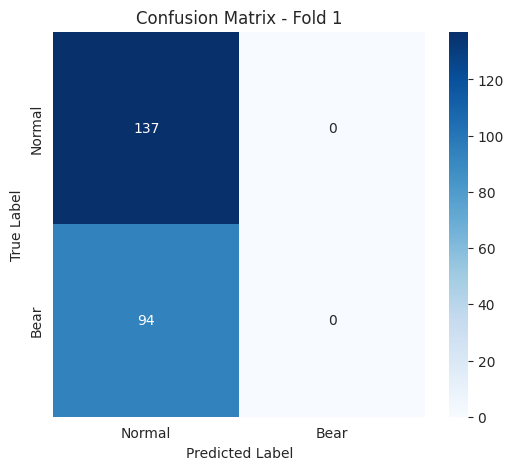


----- Fold 2 -----
Accuracy: 0.8095
Precision (Bear): 0.0000
Recall (Bear): 0.0000
F1-Score (Bear): 0.0000

Confusion Matrix:
[[187  12]
 [ 32   0]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.94      0.89       199
        Bear       0.00      0.00      0.00        32

    accuracy                           0.81       231
   macro avg       0.43      0.47      0.45       231
weighted avg       0.74      0.81      0.77       231



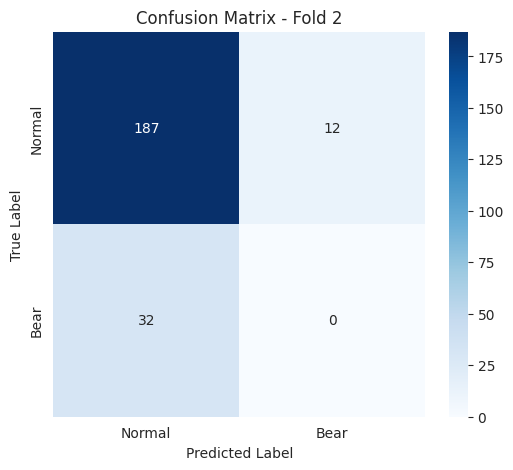


----- Fold 3 -----
Accuracy: 0.8571
Precision (Bear): 0.5000
Recall (Bear): 0.0303
F1-Score (Bear): 0.0571

Confusion Matrix:
[[197   1]
 [ 32   1]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.99      0.92       198
        Bear       0.50      0.03      0.06        33

    accuracy                           0.86       231
   macro avg       0.68      0.51      0.49       231
weighted avg       0.81      0.86      0.80       231



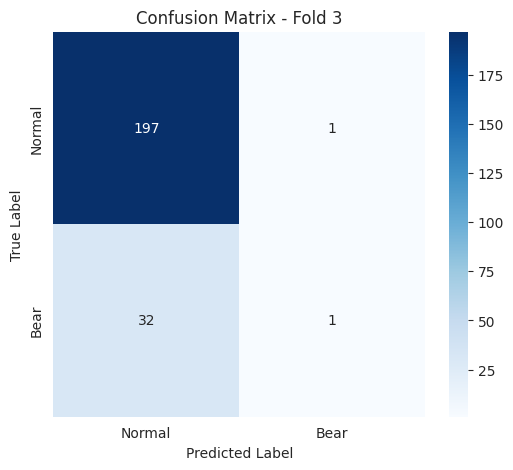


----- Fold 4 -----
Accuracy: 0.4632
Precision (Bear): 0.0841
Recall (Bear): 0.2571
F1-Score (Bear): 0.1268

Confusion Matrix:
[[98 98]
 [26  9]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.79      0.50      0.61       196
        Bear       0.08      0.26      0.13        35

    accuracy                           0.46       231
   macro avg       0.44      0.38      0.37       231
weighted avg       0.68      0.46      0.54       231



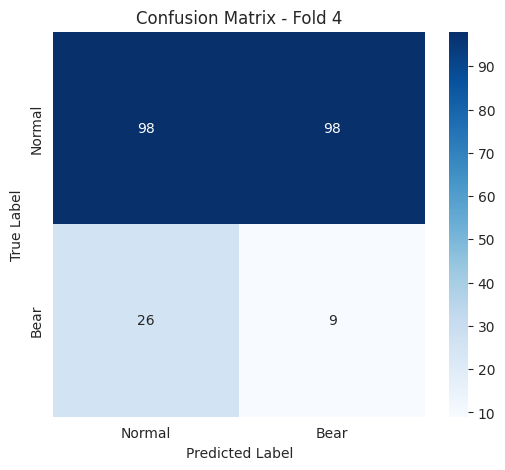


----- Fold 5 -----
Accuracy: 0.8182
Precision (Bear): 0.1333
Recall (Bear): 0.2000
F1-Score (Bear): 0.1600

Confusion Matrix:
[[185  26]
 [ 16   4]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.88      0.90       211
        Bear       0.13      0.20      0.16        20

    accuracy                           0.82       231
   macro avg       0.53      0.54      0.53       231
weighted avg       0.85      0.82      0.83       231



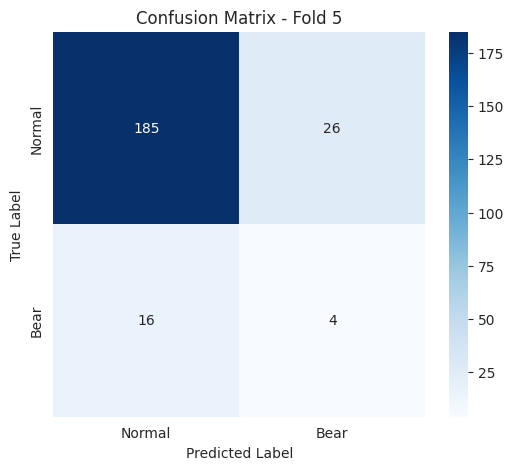


----- 全体的な評価 -----
平均Accuracy: 0.7082
平均Precision (Bear): 0.1435
平均Recall (Bear): 0.0975
平均F1-Score (Bear): 0.0688


In [148]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
import random
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
np.random.seed(seed)
random.seed(seed)

# TimeSeriesSplit の設定
tscv = TimeSeriesSplit(n_splits=5) # 5分割で評価

all_fold_accuracies = []
all_fold_precisions = []
all_fold_recalls = []
all_fold_f1_scores = []
all_fold_cm = []
# all_fold_reports = [] # For overall summary if needed

print("RandomForestモデルの学習とTimeSeriesSplitでの評価を開始します...")

# BearラベルのRecallを重視するため、ターゲット名を明確にする
target_names = ['Normal', 'Bear'] # 0: Normal, 1: Bear

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_bear)): # Changed to X_bear, y_bear
    print(f"\n----- Fold {fold + 1} -----")
    X_train, X_test = X_bear.iloc[train_idx], X_bear.iloc[test_idx]
    y_train, y_test = y_bear.iloc[train_idx], y_bear.iloc[test_idx]

    # スケーリング
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # RandomForestClassifier の初期化と学習
    # class_weight='balanced' を設定
    model = RandomForestClassifier(n_estimators=100, random_state=seed, class_weight='balanced', n_jobs=-1)
    model.fit(X_train_scaled, y_train)

    # 予測
    y_pred = model.predict(X_test_scaled)

    # 評価
    accuracy = accuracy_score(y_test, y_pred)
    # precision_bear, recall_bear, f1_bear for the positive class (Bear=1)
    precision_bear = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_bear = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_bear = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Bear): {precision_bear:.4f}")
    print(f"Recall (Bear): {recall_bear:.4f}")
    print(f"F1-Score (Bear): {f1_bear:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(report)

    all_fold_accuracies.append(accuracy)
    all_fold_precisions.append(precision_bear)
    all_fold_recalls.append(recall_bear)
    all_fold_f1_scores.append(f1_bear)
    all_fold_cm.append(cm)

    # Confusion Matrixの可視化
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

print("\n----- 全体的な評価 -----")
print(f"平均Accuracy: {np.mean(all_fold_accuracies):.4f}")
print(f"平均Precision (Bear): {np.mean(all_fold_precisions):.4f}")
print(f"平均Recall (Bear): {np.mean(all_fold_recalls):.4f}")
print(f"平均F1-Score (Bear): {np.mean(all_fold_f1_scores):.4f}")


===== Feature Importances (RandomForest Classifier) =====
           Feature  Importance
16    SMA_diff_abs    0.089500
21          VOL_20    0.065574
8              ATR    0.042466
15  ADX_normalized    0.041912
14             ADX    0.041599
1           SMA_25    0.040769
10        Lower_BB    0.039989
11        BB_Width    0.039302
5             MACD    0.036976
9         Upper_BB    0.034396


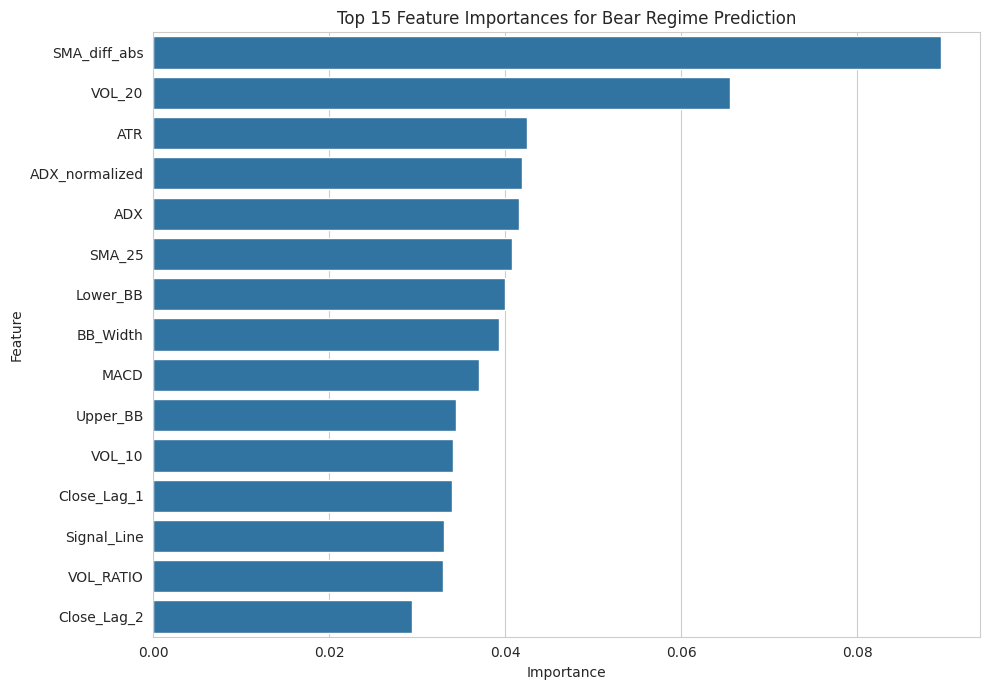

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the last trained model from TimeSeriesSplit (last fold) is available in 'model'
# And X_bear.columns contains the feature names

if 'model' in locals() and 'X_bear' in globals():
    feature_importances = model.feature_importances_
    features = X_bear.columns

    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print("\n===== Feature Importances (RandomForest Classifier) =====")
    print(importance_df.head(10))

    # Plotting feature importances
    plt.figure(figsize=(10, 7))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
    plt.title('Top 15 Feature Importances for Bear Regime Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Error: Model or X_bear not found. Please ensure previous cells (model training) were executed.")

### ウォークフォワード検証の結果概要

In [137]:
import json
import pandas as pd
import os

try:
    # Use the correct path to the best_params.json file defined in LUK3w6ls2Gkq
    with open(BEST_PARAMS_PATH, "r") as f:
        best_result_data = json.load(f)

    # The save_callback only saves the 'score', 'model_params', and 'strategy_params'.
    # 'fold_metrics' and 'total_trades_overall' are not stored in best_params.json.
    best_score = best_result_data.get("score")
    fold_metrics = best_result_data.get("fold_metrics")
    total_trades_overall = best_result_data.get("total_trades_overall")

    print("===== Optuna最適化のベストスコア =====")
    if best_score is not None:
        print(f"総合スコア: {best_score:.4f}")
    else:
        print("総合スコア: N/A (スコアがJSONファイルに見つかりません)")

    if fold_metrics:
        df_fold_results = pd.DataFrame(fold_metrics)
        print("\n===== ウォークフォワード各フォールドのメトリクス =====")
        display(df_fold_results)
        print("\n===== ウォークフォワードメトリクス (平均) =====")
        display(df_fold_results.mean().to_frame().T)
    else:
        print("\n注: 各フォールドのメトリクスと総取引回数はbest_params.jsonに保存されていないため表示されません。")

    if total_trades_overall is not None:
        print(f"\n全フォールドでの総取引回数: {total_trades_overall}")
    else:
        print("\n全フォールドでの総取引回数: N/A (総取引回数がJSONファイルに見つかりません)")


except FileNotFoundError:
    print(f"エラー: {BEST_PARAMS_PATH} が見つかりません。Optunaの実行を確認してください。")
except Exception as e:
    print(f"エラー発生: {e}")

===== Optuna最適化のベストスコア =====
総合スコア: 38.7487

===== ウォークフォワード各フォールドのメトリクス =====


,sharpe,total_return,max_dd,total_trades,pf,win_rate
0,3.326037,29.411376,-0.072650,17,1.944144,64.705882
1,-1.649178,-12.406791,-0.147515,22,0.727386,31.818182
2,0.144734,0.868729,-0.082503,22,1.028972,45.454545
3,2.829779,27.320745,-0.044661,21,1.722042,52.380952
4,0.892504,3.529932,-0.042485,20,1.177210,50.000000
5,1.543664,13.210304,-0.057351,13,1.483295,38.461538
6,0.532474,3.938427,-0.119553,19,1.120918,36.842105
7,1.403671,14.111527,-0.076020,18,1.359877,44.444444
8,2.683645,23.841622,-0.077144,18,1.602479,61.111111
9,2.198263,16.576929,-0.046322,16,1.591922,50.000000



===== ウォークフォワードメトリクス (平均) =====


,sharpe,total_return,max_dd,total_trades,pf,win_rate
0,1.390559,12.04028,-0.07662,18.6,1.375824,47.521876



全フォールドでの総取引回数: 186


In [138]:
# import os

# # Optunaのデータベースファイルを削除
# try:
#     os.remove(DB_PATH)
#     print(f"Optunaデータベースファイル '{DB_PATH}' を削除しました。")
# except FileNotFoundError:
#     print(f"Optunaデータベースファイル '{DB_PATH}' は見つかりませんでした。")

# # best_params.json ファイルを削除
# try:
#     os.remove(BEST_PARAMS_PATH)
#     print(f"ベストパラメータファイル '{BEST_PARAMS_PATH}' を削除しました。")
# except FileNotFoundError:
#     print(f"ベストパラメータファイル '{BEST_PARAMS_PATH}' は見つかりませんでした。")

# print("Optunaの学習履歴とベストパラメータがリセットされました。再度学習を開始する場合は、関連セルを再実行してください。")